In [1]:
import os
import numpy as np
import pandas as pd
from glob import glob
import json
import re
import matplotlib.pyplot as plt

In [2]:
plot_metrics = ['anli_r1', 'anli_r2', 'anli_r3', 'hellaswag', 'lambada_standard', 'lambada_openai', 'openbookqa', 'paloma_wikitext_103', 'truthfulqa_mc2', 'winogrande', 'squad_completion', 'boolq', 'piqa', 'arc_easy', 'arc_challenge', 'gsm8k', 'mmlu', 'mmlu_pro', 'medmcqa', 'agieval_en', 'squadv2', 'drop', 'triviaqa', 'bbh', 'gpqa_main_zeroshot']

# remove the metrics that are too small and have no actual meaning.
invalid_metrics = ['gsm8k', 'mmlu_pro', 'drop', 'triviaqa', 'bbh', 'gpqa_main_zeroshot']
plot_metrics = [m for m in plot_metrics if m not in invalid_metrics]

metric_keys = [
    'acc_norm,none',
    'acc,none',
    'exact_match,strict-match',
    'exact_match,flexible-extract',
    'exact_match,custom-extract',
    'exact,none',
    'exact_match,remove_whitespace',
    'exact_match,remove_whitespace_strict',
    'exact_match,get-answer',
    'f1,none',
    'contains,none',
    'perplexity,none',
    'word_perplexity,none'
]

def extract_number_from_filename(filename):
    """Extract the number from filename like 'lm_eval_begin_0.json' or 'lm_eval_interval_1221.json'"""
    # Remove .json extension and split by underscore
    name_without_ext = filename.replace('.json', '')
    parts = name_without_ext.split('_')
    # The number is always the last part
    return int(parts[-1].replace('step', ''))

def parse_experiment_filename(filename):
    """
    Parse experiment folder name into structured components.
    
    Handles multiple formats:
    1. Standard: midtrain_gpt2_{dataset}_lr-{lr}_token-{tokens}_disp-{disp_type}-{disp_value}-all_fewshot-{fewshot}_maxsample-{maxsample}_seed-{seed}{suffix}
    2. Complex: midtrain_gpt2_{dataset}_{complex_params}_{hash}
    
    For complex format:
    - infonce_cosine-cXpY-taucos-ZpW means coefficient=X.Y, tau_cosine=Z.W
    - infonce_l2-cXpY-taul2-ZpW means coefficient=X.Y, tau_l2=Z.W
    - Standard format disp-infonce_*-V means coefficient=V with default tau=0.5
    
    Gradient clipping:
    - clip0.5 or old_clip05 suffix means gradient_clip=0.5
    - No clipping suffix means gradient_clip=1.0
    
    Returns dict with keys: dataset, lr, tokens, disp_type, disp_value, tau_cosine, tau_l2, fewshot, maxsample, seed, suffix, config_hash, gradient_clip
    """
    # Remove 'midtrain_gpt2_' prefix
    if not filename.startswith('midtrain_gpt2_'):
        raise ValueError(f"Unexpected filename format: {filename}")
    
    name = filename[len('midtrain_gpt2_'):]
    
    result = {
        'dataset': None,
        'lr': None,
        'tokens': None,
        'disp_type': None,
        'disp_value': None,  # coefficient
        'tau_cosine': None,  # tau parameter for cosine (default 0.5)
        'tau_l2': None,      # tau parameter for l2 (default 0.5)
        'fewshot': None,
        'maxsample': None,
        'seed': None,
        'suffix': None,
        'config_hash': None,
        'gradient_clip': 1.0  # default gradient clipping
    }
    
    # Extract dataset (first component)
    if name.startswith('Salesforce-wikitext_'):
        result['dataset'] = 'Salesforce-wikitext'
        name = name[len('Salesforce-wikitext_'):]
    elif name.startswith('Skylion007-openwebtext_'):
        result['dataset'] = 'Skylion007-openwebtext'
        name = name[len('Skylion007-openwebtext_'):]
    else:
        # Handle other datasets or complex formats
        # Look for the first underscore after a potential dataset name
        first_underscore = name.find('_')
        if first_underscore > 0:
            result['dataset'] = name[:first_underscore]
            name = name[first_underscore + 1:]
        else:
            result['dataset'] = name
            name = ''
    
    # Check if this is a complex format (contains hash at the end)
    hash_match = re.search(r'_([a-f0-9]{8,})$', name)
    if hash_match:
        result['config_hash'] = hash_match.group(1)
        name = name[:hash_match.start()]
    
    # Extract suffix if present - check for gradient clipping first
    suffix_patterns = ['old_clip05', 'clip0.5', '_old_old', '_old']
    for suffix in suffix_patterns:
        if name.endswith(suffix):
            result['suffix'] = suffix
            name = name[:-len(suffix)]
            # Set gradient clipping based on suffix
            if 'clip05' in suffix or 'clip0.5' in suffix:
                result['gradient_clip'] = 0.5
            break
    
    # Try to parse standard format components
    # lr-{lr}
    lr_match = re.search(r'lr-([0-9e\.-]+)_?', name)
    if lr_match:
        result['lr'] = lr_match.group(1)
        name = name.replace(lr_match.group(0), '', 1)
    
    # token-{tokens}
    token_match = re.search(r'token-([0-9]+)_?', name)
    if token_match:
        result['tokens'] = int(token_match.group(1))
        name = name.replace(token_match.group(0), '', 1)
    
    # disp-{disp_type}-{disp_value}
    disp_match = re.search(r'disp-([^-]+)-([^-]+)_?', name)
    if disp_match:
        result['disp_type'] = disp_match.group(1)
        result['disp_value'] = disp_match.group(2)
        # For standard format, set default tau values
        if result['disp_type'] == 'infonce_cosine':
            result['tau_cosine'] = 0.5
        elif result['disp_type'] == 'infonce_l2':
            result['tau_l2'] = 0.5
        name = name.replace(disp_match.group(0), '', 1)
    
    # all_fewshot-{fewshot}
    fewshot_match = re.search(r'all_fewshot-([0-9]+)_?', name)
    if fewshot_match:
        result['fewshot'] = int(fewshot_match.group(1))
        name = name.replace(fewshot_match.group(0), '', 1)
    
    # maxsample-{maxsample}
    maxsample_match = re.search(r'maxsample-([0-9]+)_?', name)
    if maxsample_match:
        result['maxsample'] = int(maxsample_match.group(1))
        name = name.replace(maxsample_match.group(0), '', 1)
    
    # seed-{seed}
    seed_match = re.search(r'seed-([0-9]+)_?', name)
    if seed_match:
        result['seed'] = int(seed_match.group(1))
        name = name.replace(seed_match.group(0), '', 1)
    
    # For complex formats, try to extract what we can
    if not result['disp_type'] and 'disp-' not in filename:
        # This is a complex format, try to extract dispersion info differently
        # Look for patterns like infonce_cosine-c0p1-taucos-0p1 or infonce_l2-c0p1-taul2-0p1
        complex_patterns = [
            r'infonce_cosine-c([0-9]+)p([0-9]+)-taucos-([0-9]+)p([0-9]+)',
            r'infonce_l2-c([0-9]+)p([0-9]+)-taul2-([0-9]+)p([0-9]+)'
        ]
        
        for pattern in complex_patterns:
            match = re.search(pattern, name)
            if match:
                c_int, c_dec, tau_int, tau_dec = match.groups()
                coeff = float(f"{c_int}.{c_dec}")
                tau_val = float(f"{tau_int}.{tau_dec}")
                
                result['disp_value'] = coeff  # coefficient
                if 'infonce_cosine' in name:
                    result['disp_type'] = 'infonce_cosine'
                    result['tau_cosine'] = tau_val
                elif 'infonce_l2' in name:
                    result['disp_type'] = 'infonce_l2'
                    result['tau_l2'] = tau_val
                break
        
        # Extract lr from complex format (lr1em05 -> 1e-05)
        lr_complex_match = re.search(r'lr([0-9]+)em([0-9]+)', name)
        if lr_complex_match:
            result['lr'] = f"{lr_complex_match.group(1)}e-{lr_complex_match.group(2)}"
        
        # Extract tokens from complex format (tok300M -> 300000000)
        token_complex_match = re.search(r'tok([0-9]+)M', name)
        if token_complex_match:
            result['tokens'] = int(token_complex_match.group(1)) * 1000000
        
        # Extract seed from complex format (s1 -> 1)
        seed_complex_match = re.search(r's([0-9]+)', name)
        if seed_complex_match:
            result['seed'] = int(seed_complex_match.group(1))
    
    return result

In [3]:
res_path = "./results/"
output_csv = './results.csv'
output_dir = "./figures/all/"
os.makedirs(output_dir, exist_ok=True)

In [4]:
res_folders = os.listdir(res_path)
result_list = []
parsed_configs = []
for res_folder in res_folders:
    if not res_folder.startswith('midtrain_gpt2'):
        continue
    # Parse the experiment configuration from folder name
    try:
        config = parse_experiment_filename(res_folder)
        parsed_configs.append(config)
    except ValueError as e:
        print(f"Warning: Could not parse folder {res_folder}: {e}")
        continue
    
    files = sorted([f for f in os.listdir(os.path.join(res_path, res_folder)) if f.startswith('lm_eval_')])
    # print(f"{res_folder}")
    for file in files:
        # print(f"{file}")
        step = extract_number_from_filename(file)
        with open(f'{res_path}/{res_folder}/{file}', 'r') as f:
            data = json.load(f)

        result = {}

        result['folder_name'] = res_folder
        result['filename'] = file
        result['step'] = step
        # Add all parsed configuration components
        result.update(config)
        
        for plot_metric in plot_metrics:
            res = data['results'][plot_metric]
            key_used = None
            for key in metric_keys:
                if key in res.keys():
                    key_used = key
                    break
            assert key_used is not None, f'no key found for {plot_metric}, possible keys: {res.keys()}'
            result_value = res[key_used]
            result_key = plot_metric + ',' + key_used
            result[result_key] = result_value

        result_list.append(result)

df = pd.DataFrame(result_list).sort_values('step')
df['squadv2,exact,none'] /= 100 # normalize squadv2 to 0-1

# Identify metric columns (exclude config columns)
config_cols = ['folder_name', 'filename', 'step', 'dataset', 'lr', 'tokens', 'disp_type', 'disp_value', 
               'tau_cosine', 'tau_l2', 'fewshot', 'maxsample', 'seed', 'suffix', 'config_hash', 'gradient_clip', 'disp']
metric_cols = [col for col in df.columns if col not in config_cols]
metric_no_ppl = [c for c in metric_cols if c != 'paloma_wikitext_103,word_perplexity,none']
df['mean_metric'] = df[metric_no_ppl].mean(axis=1)

# Check for duplicate configurations and remove them
config_cols = ['dataset', 'lr', 'tokens', 'disp_type', 'disp_value', 'tau_cosine', 'tau_l2', 'fewshot', 'maxsample', 'seed', 'gradient_clip']

# Properly map folders to their parsed configs
config_to_folders = {}
for res_folder in res_folders:
    if not res_folder.startswith('midtrain_gpt2'):
        continue
    try:
        config = parse_experiment_filename(res_folder)
        config_key = tuple(config.get(col, '__NONE__') for col in config_cols)
        if config_key not in config_to_folders:
            config_to_folders[config_key] = []
        config_to_folders[config_key].append(res_folder)
    except ValueError:
        continue

# Find duplicates
duplicate_folders = []
folders_to_keep = []
for config_key, folder_list in config_to_folders.items():
    if len(folder_list) > 1:
        folders_to_keep.append(folder_list[0])  # Keep first
        duplicate_folders.extend(folder_list[1:])  # Mark rest for removal

if duplicate_folders:
    print(f"Found duplicate configurations - removing {len(duplicate_folders)} duplicate folders")
    print(f"Duplicate folders to remove: {duplicate_folders}")
    
    # Filter df to exclude duplicate folders
    df = df[~df['folder_name'].isin(duplicate_folders)]
    print(f"DataFrame reduced from {len(df) + len(duplicate_folders)*11} to {len(df)} rows")
else:
    print("No duplicate configurations found")

df.to_csv(f'{output_dir}/{output_csv}', index=False)

Found duplicate configurations - removing 2 duplicate folders
Duplicate folders to remove: ['midtrain_gpt2_Salesforce-wikitext_lr-1e-05_token-300000000_disp-None-1-all_fewshot-1_maxsample-100_seed-1', 'midtrain_gpt2_Salesforce-wikitext_lr-1e-05_token-300000000_disp-infonce_l2-0.1-all_fewshot-1_maxsample-100_seed-1_old']
DataFrame reduced from 403 to 381 rows


In [5]:
df.groupby('folder_name')

In [6]:
df[(df['dataset'] == 'Salesforce-wikitext') & (df['step'] == df['step'].max())].sort_values('paloma_wikitext_103,word_perplexity,none', ascending=True).head(20)

,folder_name,filename,step,dataset,lr,tokens,disp_type,disp_value,tau_cosine,tau_l2,...,"squad_completion,contains,none","boolq,acc,none","piqa,acc_norm,none","arc_easy,acc_norm,none","arc_challenge,acc_norm,none","mmlu,acc,none","medmcqa,acc_norm,none","agieval_en,acc,none","squadv2,exact,none",mean_metric
318,midtrain_gpt2_Salesforce-wikitext_infonce_cosi...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,infonce_cosine,0.1,0.5,NaN,...,0.17,0.48,0.61,0.34,0.22,0.253333,0.25,0.234,0.47,0.362646
23,midtrain_gpt2_Salesforce-wikitext_infonce_cosi...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,infonce_cosine,0.1,0.1,NaN,...,0.18,0.49,0.61,0.35,0.22,0.253684,0.25,0.235,0.49,0.366749
99,midtrain_gpt2_Salesforce-wikitext_infonce_cosi...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,infonce_cosine,0.1,1.0,NaN,...,0.20,0.45,0.61,0.36,0.23,0.251404,0.27,0.237,0.48,0.367674
252,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,infonce_cosine,0.5,0.5,NaN,...,0.18,0.49,0.62,0.35,0.23,0.253860,0.26,0.235,0.48,0.367644
230,midtrain_gpt2_Salesforce-wikitext_infonce_cosi...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,infonce_cosine,1.0,1.0,NaN,...,0.21,0.46,0.61,0.36,0.22,0.257193,0.23,0.237,0.46,0.362112
197,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,hinge,0.1,NaN,NaN,...,0.22,0.48,0.62,0.36,0.22,0.256667,0.26,0.235,0.47,0.367059
241,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,covariance,0.5,NaN,NaN,...,0.27,0.50,0.62,0.36,0.22,0.255263,0.25,0.237,0.38,0.370984
1,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,None,1,NaN,NaN,...,0.19,0.48,0.60,0.35,0.22,0.256491,0.24,0.241,0.47,0.364157
296,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,infonce_cosine,1.0,0.5,NaN,...,0.24,0.47,0.60,0.34,0.21,0.255614,0.27,0.233,0.47,0.364043
208,midtrain_gpt2_Salesforce-wikitext_infonce_cosi...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,infonce_cosine,1.0,0.5,NaN,...,0.22,0.48,0.61,0.35,0.22,0.256667,0.27,0.239,0.47,0.368470


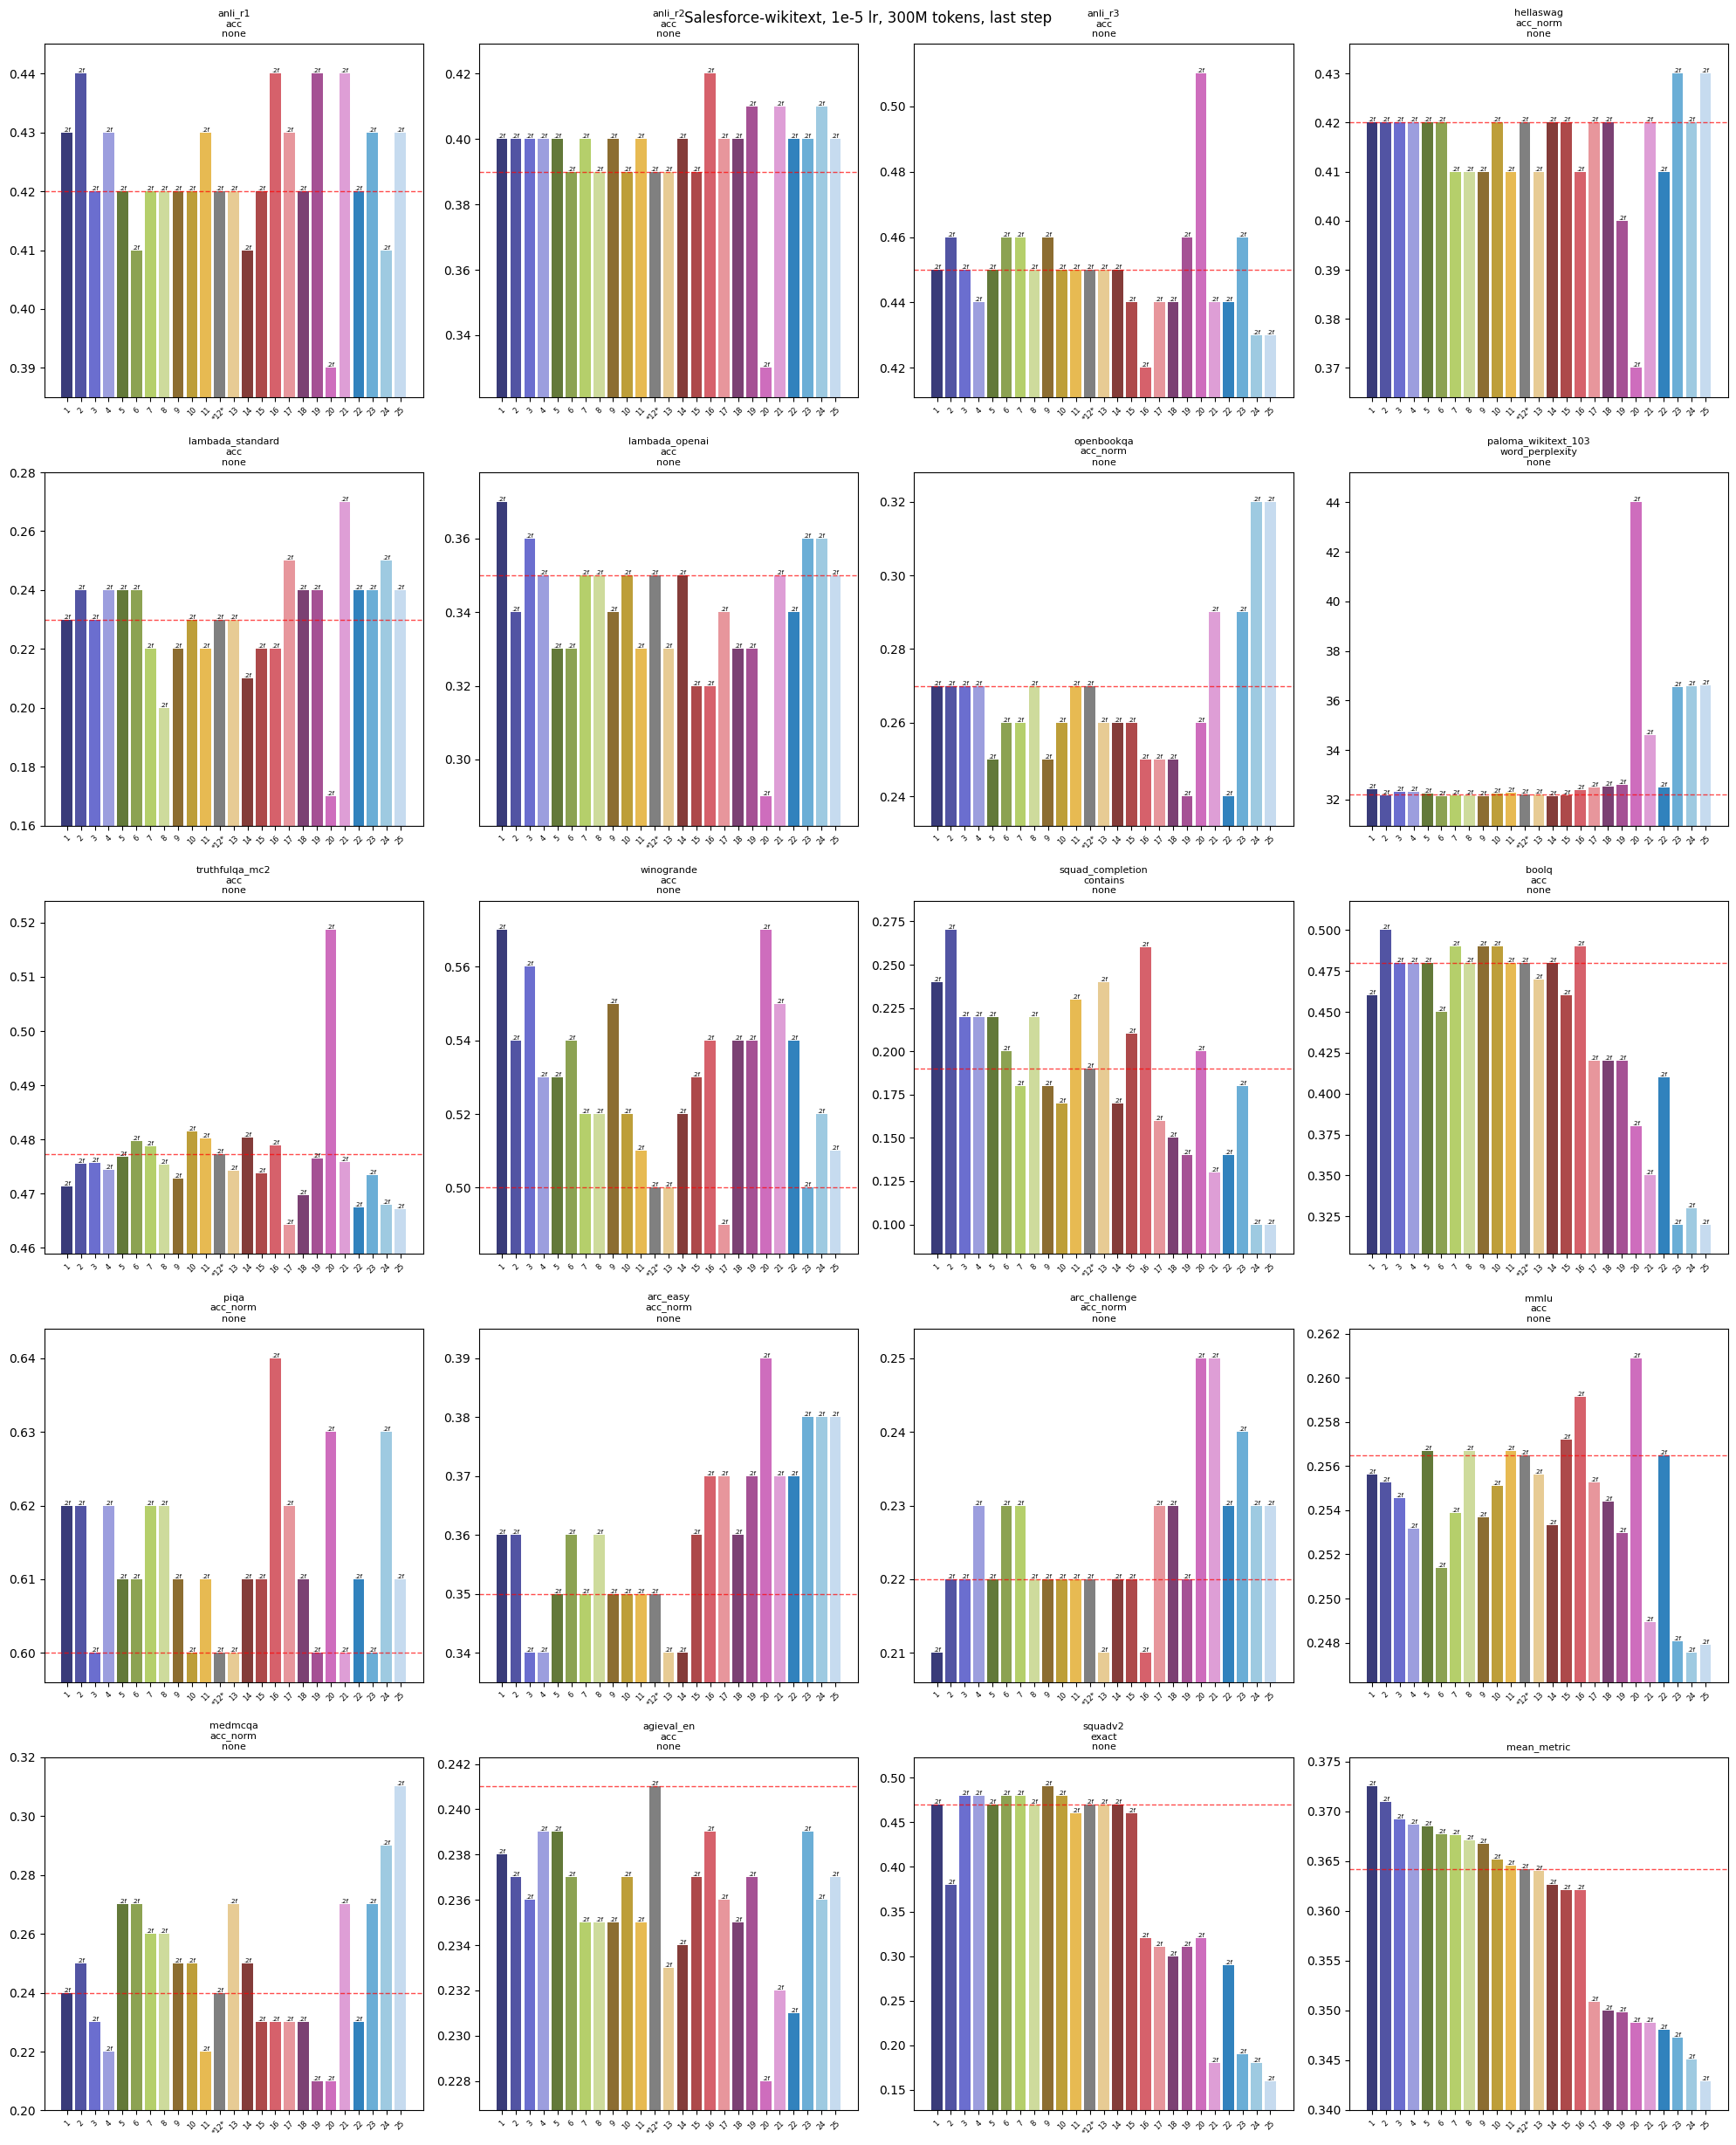

Improvement of best setting over None setting: 0.37-0.36=0.83


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Get colors from two good colormaps
colors1 = plt.cm.tab20b.colors
colors2 = plt.cm.tab20c.colors

# Combine them and create the new map
custom_cmap = ListedColormap(colors1 + colors2)

# Create 'disp' column if it doesn't exist
if 'disp' not in df.columns:
    df['disp'] = df.apply(lambda row: f"{row['disp_type']}-{row['disp_value']}" if pd.notna(row['disp_type']) else 'None', axis=1)

# Filter and sort data
filtered_df = df[(df['dataset'] == 'Salesforce-wikitext') & (df['step'] == df['step'].max())]

# sorted_df = filtered_df.sort_values('paloma_wikitext_103,word_perplexity,none', ascending=True)
sorted_df = filtered_df.sort_values('mean_metric', ascending=False)

# Identify metric columns (exclude config columns)
config_cols = ['folder_name', 'filename', 'step', 'dataset', 'lr', 'tokens', 'disp_type', 'disp_value', 
               'tau_cosine', 'tau_l2', 'fewshot', 'maxsample', 'seed', 'suffix', 'config_hash', 'gradient_clip', 'disp']
metric_cols = [col for col in df.columns if col not in config_cols]

# Create discrete color map - gray for None, discrete colors for others
none_indices = [i for i, disp_val in enumerate(sorted_df['disp']) if disp_val.startswith('None')]
other_indices = [i for i in range(len(sorted_df)) if i not in none_indices]

# Use tab10 colormap for discrete colors
cmap = custom_cmap
colors = ['gray'] * len(sorted_df)  # Start with all gray
for i, idx in enumerate(other_indices):
    colors[idx] = cmap(i)  # Cycle through 10 discrete colors

# Get None values for reference lines
none_values = {}
for metric in metric_cols:
    none_row = sorted_df[sorted_df['disp'].str.startswith('None')]
    if not none_row.empty:
        none_values[metric] = none_row[metric].iloc[0]
    else:
        none_values[metric] = None

# Create subplots
n_metrics = len(metric_cols)
n_cols = 4
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Plot each metric
for i, metric in enumerate(metric_cols):
    row, col = i // n_cols, i % n_cols
    ax = axes[row, col]
    
    values = sorted_df[metric].values
    bars = ax.bar(range(len(sorted_df)), values, color=colors)
    
    # Set y-axis limits with margin
    if len(values) > 0:
        y_min = np.min(values)
        y_max = np.max(values)
        y_margin = (y_max - y_min) * 0.1 if y_max != y_min else abs(y_min) * 0.1
        ax.set_ylim(y_min - y_margin, y_max + y_margin)
    
    ax.set_title(metric.replace(',', '\n'), fontsize=8)
    ax.set_xticks(range(len(sorted_df)))
    
    # Create tick labels - highlight None with asterisks
    tick_labels = []
    for j, disp_val in enumerate(sorted_df['disp']):
        if disp_val.startswith('None'):
            tick_labels.append(f"*{j+1}*")  # Special markers for None
        else:
            tick_labels.append(f"{j+1}")
    
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=6)
    
    # Add horizontal dashed line at None value
    if none_values[metric] is not None:
        ax.axhline(y=none_values[metric], color='red', linestyle='--', alpha=0.7, linewidth=1)
    
    # Add value labels on bars (only for significant values)
    for j, v in enumerate(values):
        if abs(v) > 1e-6:  # Only label non-zero values
            ax.text(j, v, '.2f', ha='center', va='bottom' if v >= 0 else 'top', fontsize=5)

# Hide empty subplots
for i in range(n_metrics, n_rows * n_cols):
    row, col = i // n_cols, i % n_cols
    axes[row, col].set_visible(False)

plt.suptitle('Salesforce-wikitext, 1e-5 lr, 300M tokens, last step')
plt.tight_layout()
plt.savefig(f'{output_dir}/metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# # Print the settings for reference
# print("Settings order (best to worst perplexity):")
# print("* = None settings (gray bars)")
# for i, (_, row) in enumerate(sorted_df.iterrows()):
#     marker = "*" if row['disp'].startswith('None') else ""
#     print(f"{marker}{i+1}: {row['disp']} (perplexity: {row['paloma_wikitext_103,word_perplexity,none']:.2f})")

# Get the best and None values
best_value = filtered_df['mean_metric'].max()
none_value = filtered_df.loc[filtered_df['disp'] == 'None-1', 'mean_metric'].iloc[0]
improvement = (best_value - none_value) * 100

print(f"Improvement of best setting over None setting: {best_value:.2f}-{none_value:.2f}={improvement:.2f}")


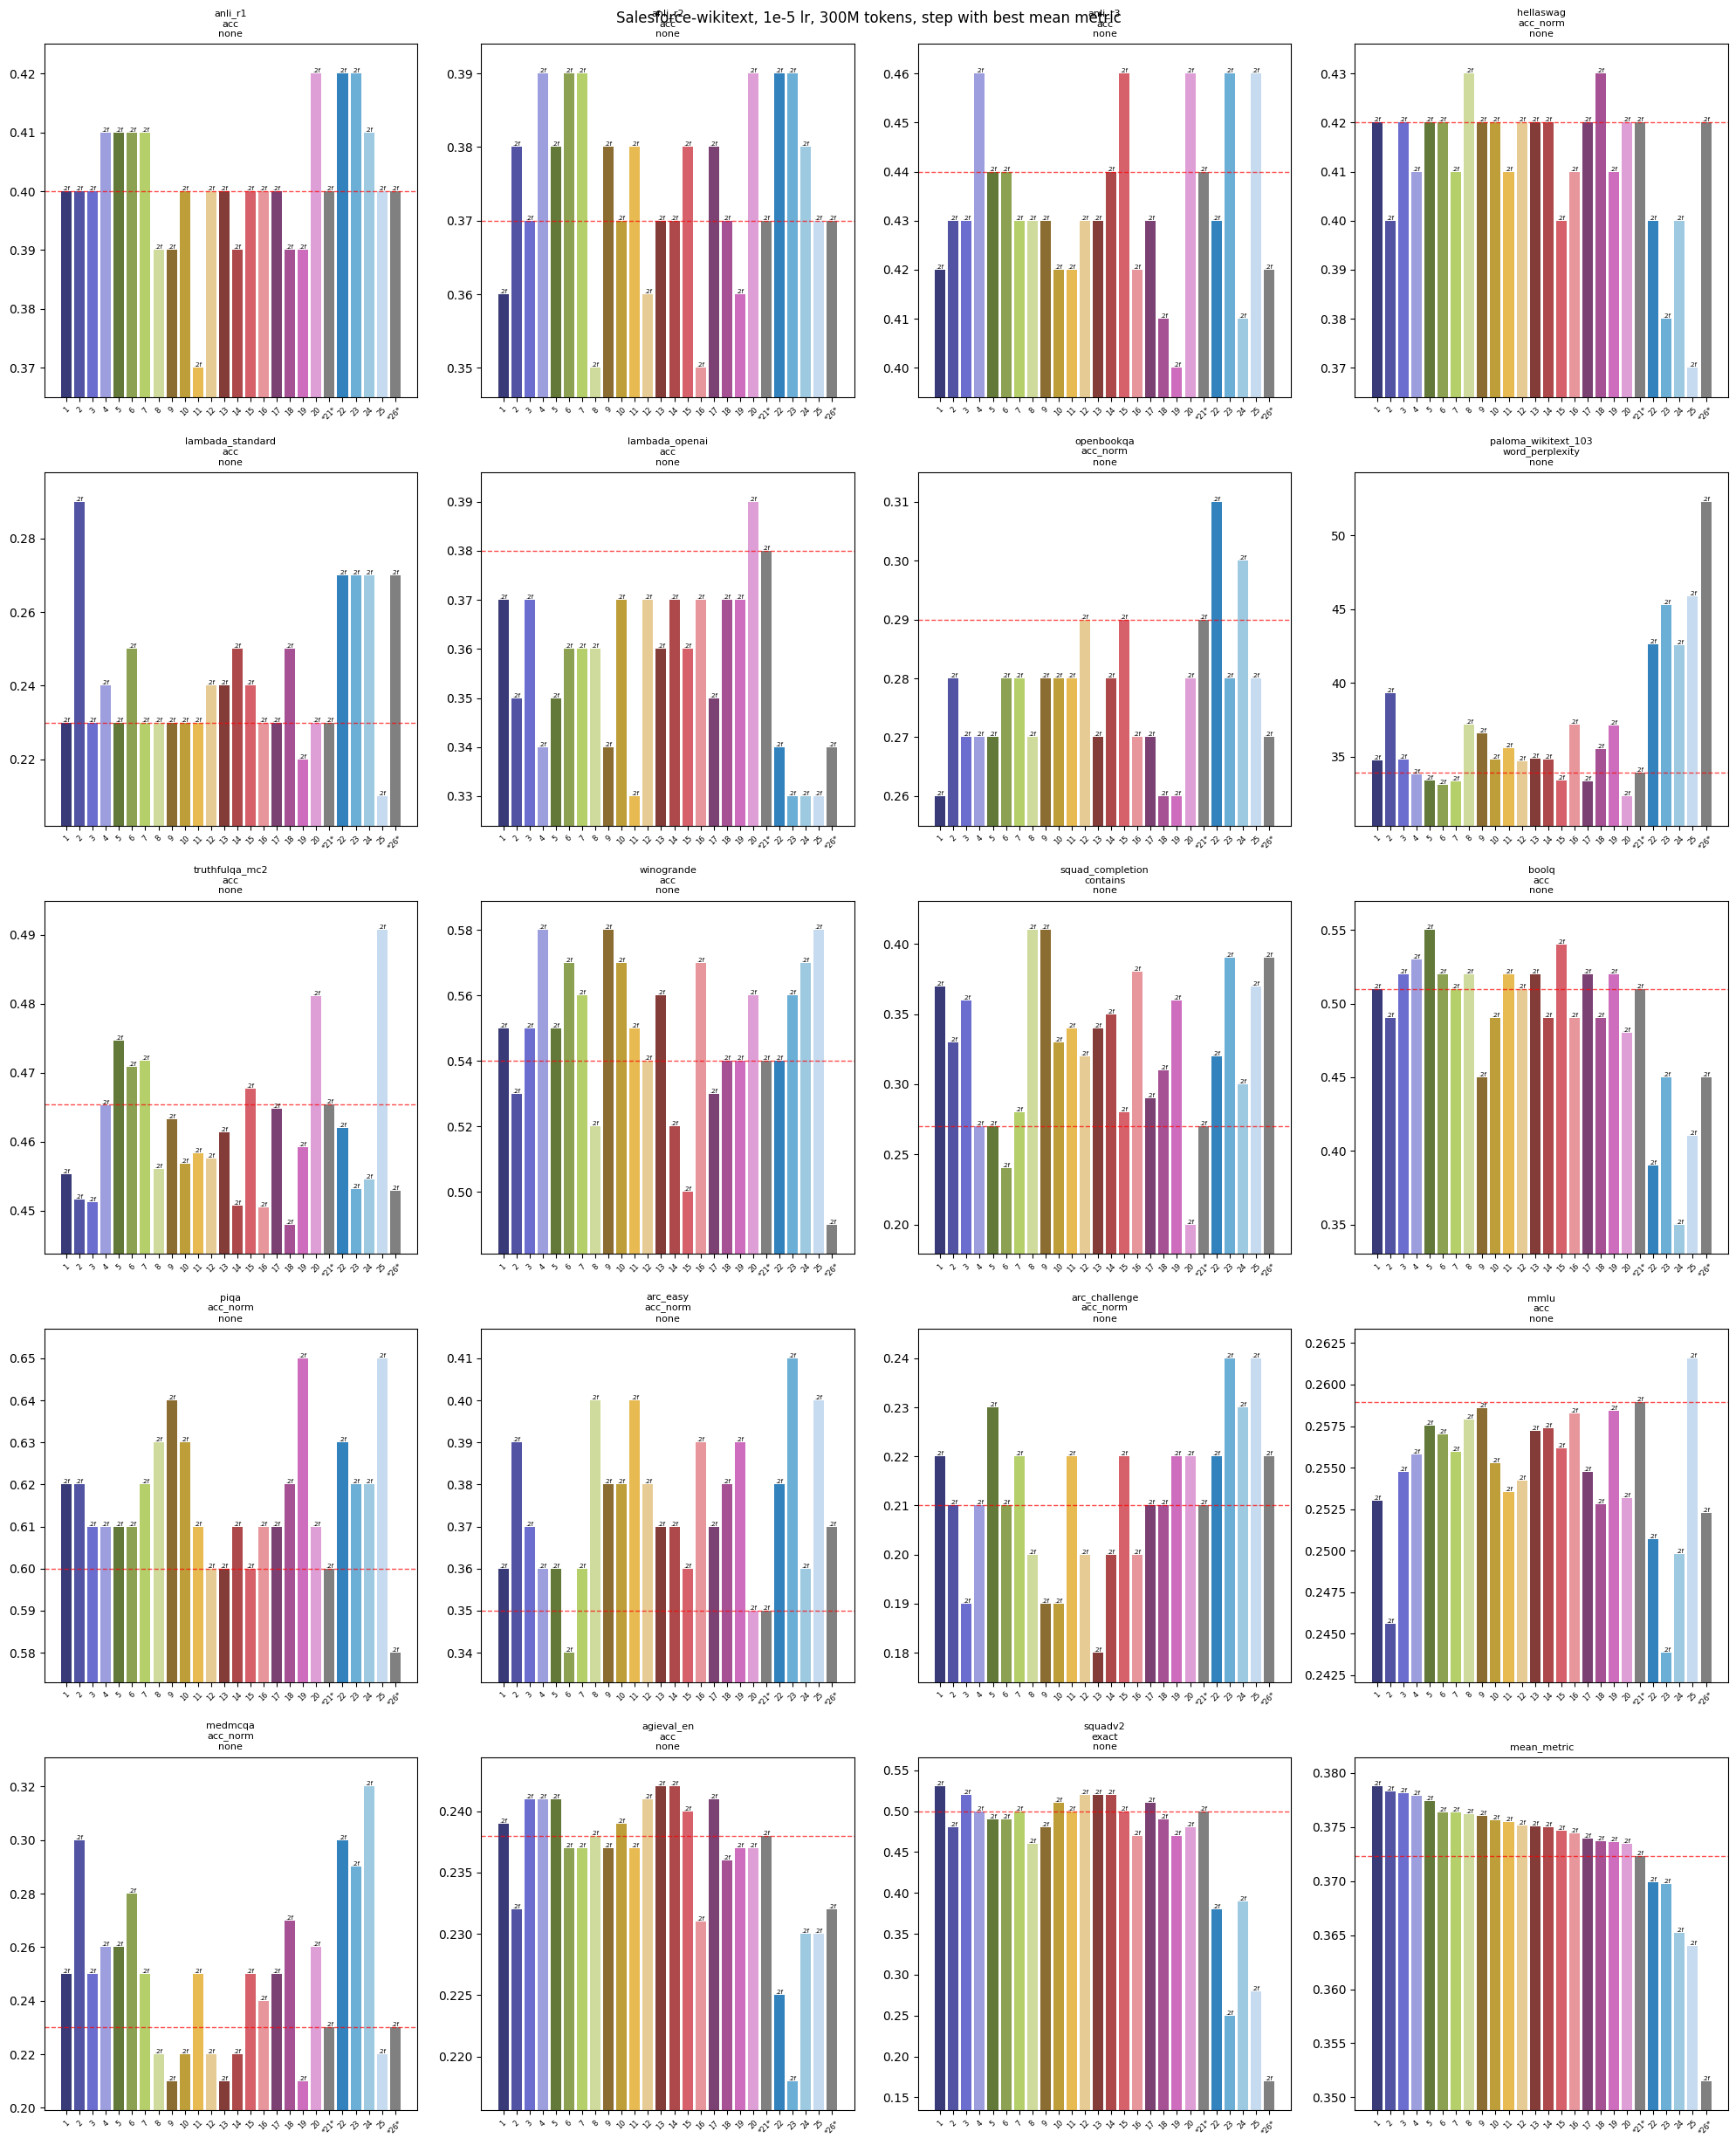

Improvement of best setting over None setting: 0.38-0.37=0.64


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Get colors from two good colormaps
colors1 = plt.cm.tab20b.colors
colors2 = plt.cm.tab20c.colors

# Combine them and create the new map
custom_cmap = ListedColormap(colors1 + colors2)

# Create 'disp' column if it doesn't exist
if 'disp' not in df.columns:
    df['disp'] = df.apply(lambda row: f"{row['disp_type']}-{row['disp_value']}" if pd.notna(row['disp_type']) else 'None', axis=1)

# Filter and sort data
# filtered_df = df[(df['dataset'] == 'Salesforce-wikitext') & (df['step'] == df['step'].max())]
# Replace with: select row with max 'mean_metric' per folder, then filter to Salesforce-wikitext
filtered_df = df.loc[df.groupby('folder_name')['mean_metric'].idxmax()].query('dataset == "Salesforce-wikitext"')

# sorted_df = filtered_df.sort_values('paloma_wikitext_103,word_perplexity,none', ascending=True)
sorted_df = filtered_df.sort_values('mean_metric', ascending=False)

# Identify metric columns (exclude config columns)
config_cols = ['folder_name', 'filename', 'step', 'dataset', 'lr', 'tokens', 'disp_type', 'disp_value', 
               'tau_cosine', 'tau_l2', 'fewshot', 'maxsample', 'seed', 'suffix', 'config_hash', 'gradient_clip', 'disp']
metric_cols = [col for col in df.columns if col not in config_cols]

# Create discrete color map - gray for None, discrete colors for others
none_indices = [i for i, disp_val in enumerate(sorted_df['disp']) if disp_val.startswith('None')]
other_indices = [i for i in range(len(sorted_df)) if i not in none_indices]

# Use tab10 colormap for discrete colors
cmap = custom_cmap
colors = ['gray'] * len(sorted_df)  # Start with all gray
for i, idx in enumerate(other_indices):
    colors[idx] = cmap(i)  # Cycle through 10 discrete colors

# Get None values for reference lines
none_values = {}
for metric in metric_cols:
    none_row = sorted_df[sorted_df['disp'].str.startswith('None')]
    if not none_row.empty:
        none_values[metric] = none_row[metric].iloc[0]
    else:
        none_values[metric] = None

# Create subplots
n_metrics = len(metric_cols)
n_cols = 4
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Plot each metric
for i, metric in enumerate(metric_cols):
    row, col = i // n_cols, i % n_cols
    ax = axes[row, col]
    
    values = sorted_df[metric].values
    bars = ax.bar(range(len(sorted_df)), values, color=colors)
    
    # Set y-axis limits with margin
    if len(values) > 0:
        y_min = np.min(values)
        y_max = np.max(values)
        y_margin = (y_max - y_min) * 0.1 if y_max != y_min else abs(y_min) * 0.1
        ax.set_ylim(y_min - y_margin, y_max + y_margin)
    
    ax.set_title(metric.replace(',', '\n'), fontsize=8)
    ax.set_xticks(range(len(sorted_df)))
    
    # Create tick labels - highlight None with asterisks
    tick_labels = []
    for j, disp_val in enumerate(sorted_df['disp']):
        if disp_val.startswith('None'):
            tick_labels.append(f"*{j+1}*")  # Special markers for None
        else:
            tick_labels.append(f"{j+1}")
    
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=6)
    
    # Add horizontal dashed line at None value
    if none_values[metric] is not None:
        ax.axhline(y=none_values[metric], color='red', linestyle='--', alpha=0.7, linewidth=1)
    
    # Add value labels on bars (only for significant values)
    for j, v in enumerate(values):
        if abs(v) > 1e-6:  # Only label non-zero values
            ax.text(j, v, '.2f', ha='center', va='bottom' if v >= 0 else 'top', fontsize=5)

# Hide empty subplots
for i in range(n_metrics, n_rows * n_cols):
    row, col = i // n_cols, i % n_cols
    axes[row, col].set_visible(False)

plt.suptitle('Salesforce-wikitext, 1e-5 lr, 300M tokens, step with best mean metric')
plt.tight_layout()
plt.savefig(f'{output_dir}/metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# # Print the settings for reference
# print("Settings order (best to worst perplexity):")
# print("* = None settings (gray bars)")
# for i, (_, row) in enumerate(sorted_df.iterrows()):
#     marker = "*" if row['disp'].startswith('None') else ""
#     print(f"{marker}{i+1}: {row['disp']} (perplexity: {row['paloma_wikitext_103,word_perplexity,none']:.2f})")

# Get the best and None values
best_value = filtered_df['mean_metric'].max()
none_value = filtered_df.loc[filtered_df['disp'] == 'None-1', 'mean_metric'].iloc[0]
improvement = (best_value - none_value) * 100

print(f"Improvement of best setting over None setting: {best_value:.2f}-{none_value:.2f}={improvement:.2f}")


# Include openwebtext

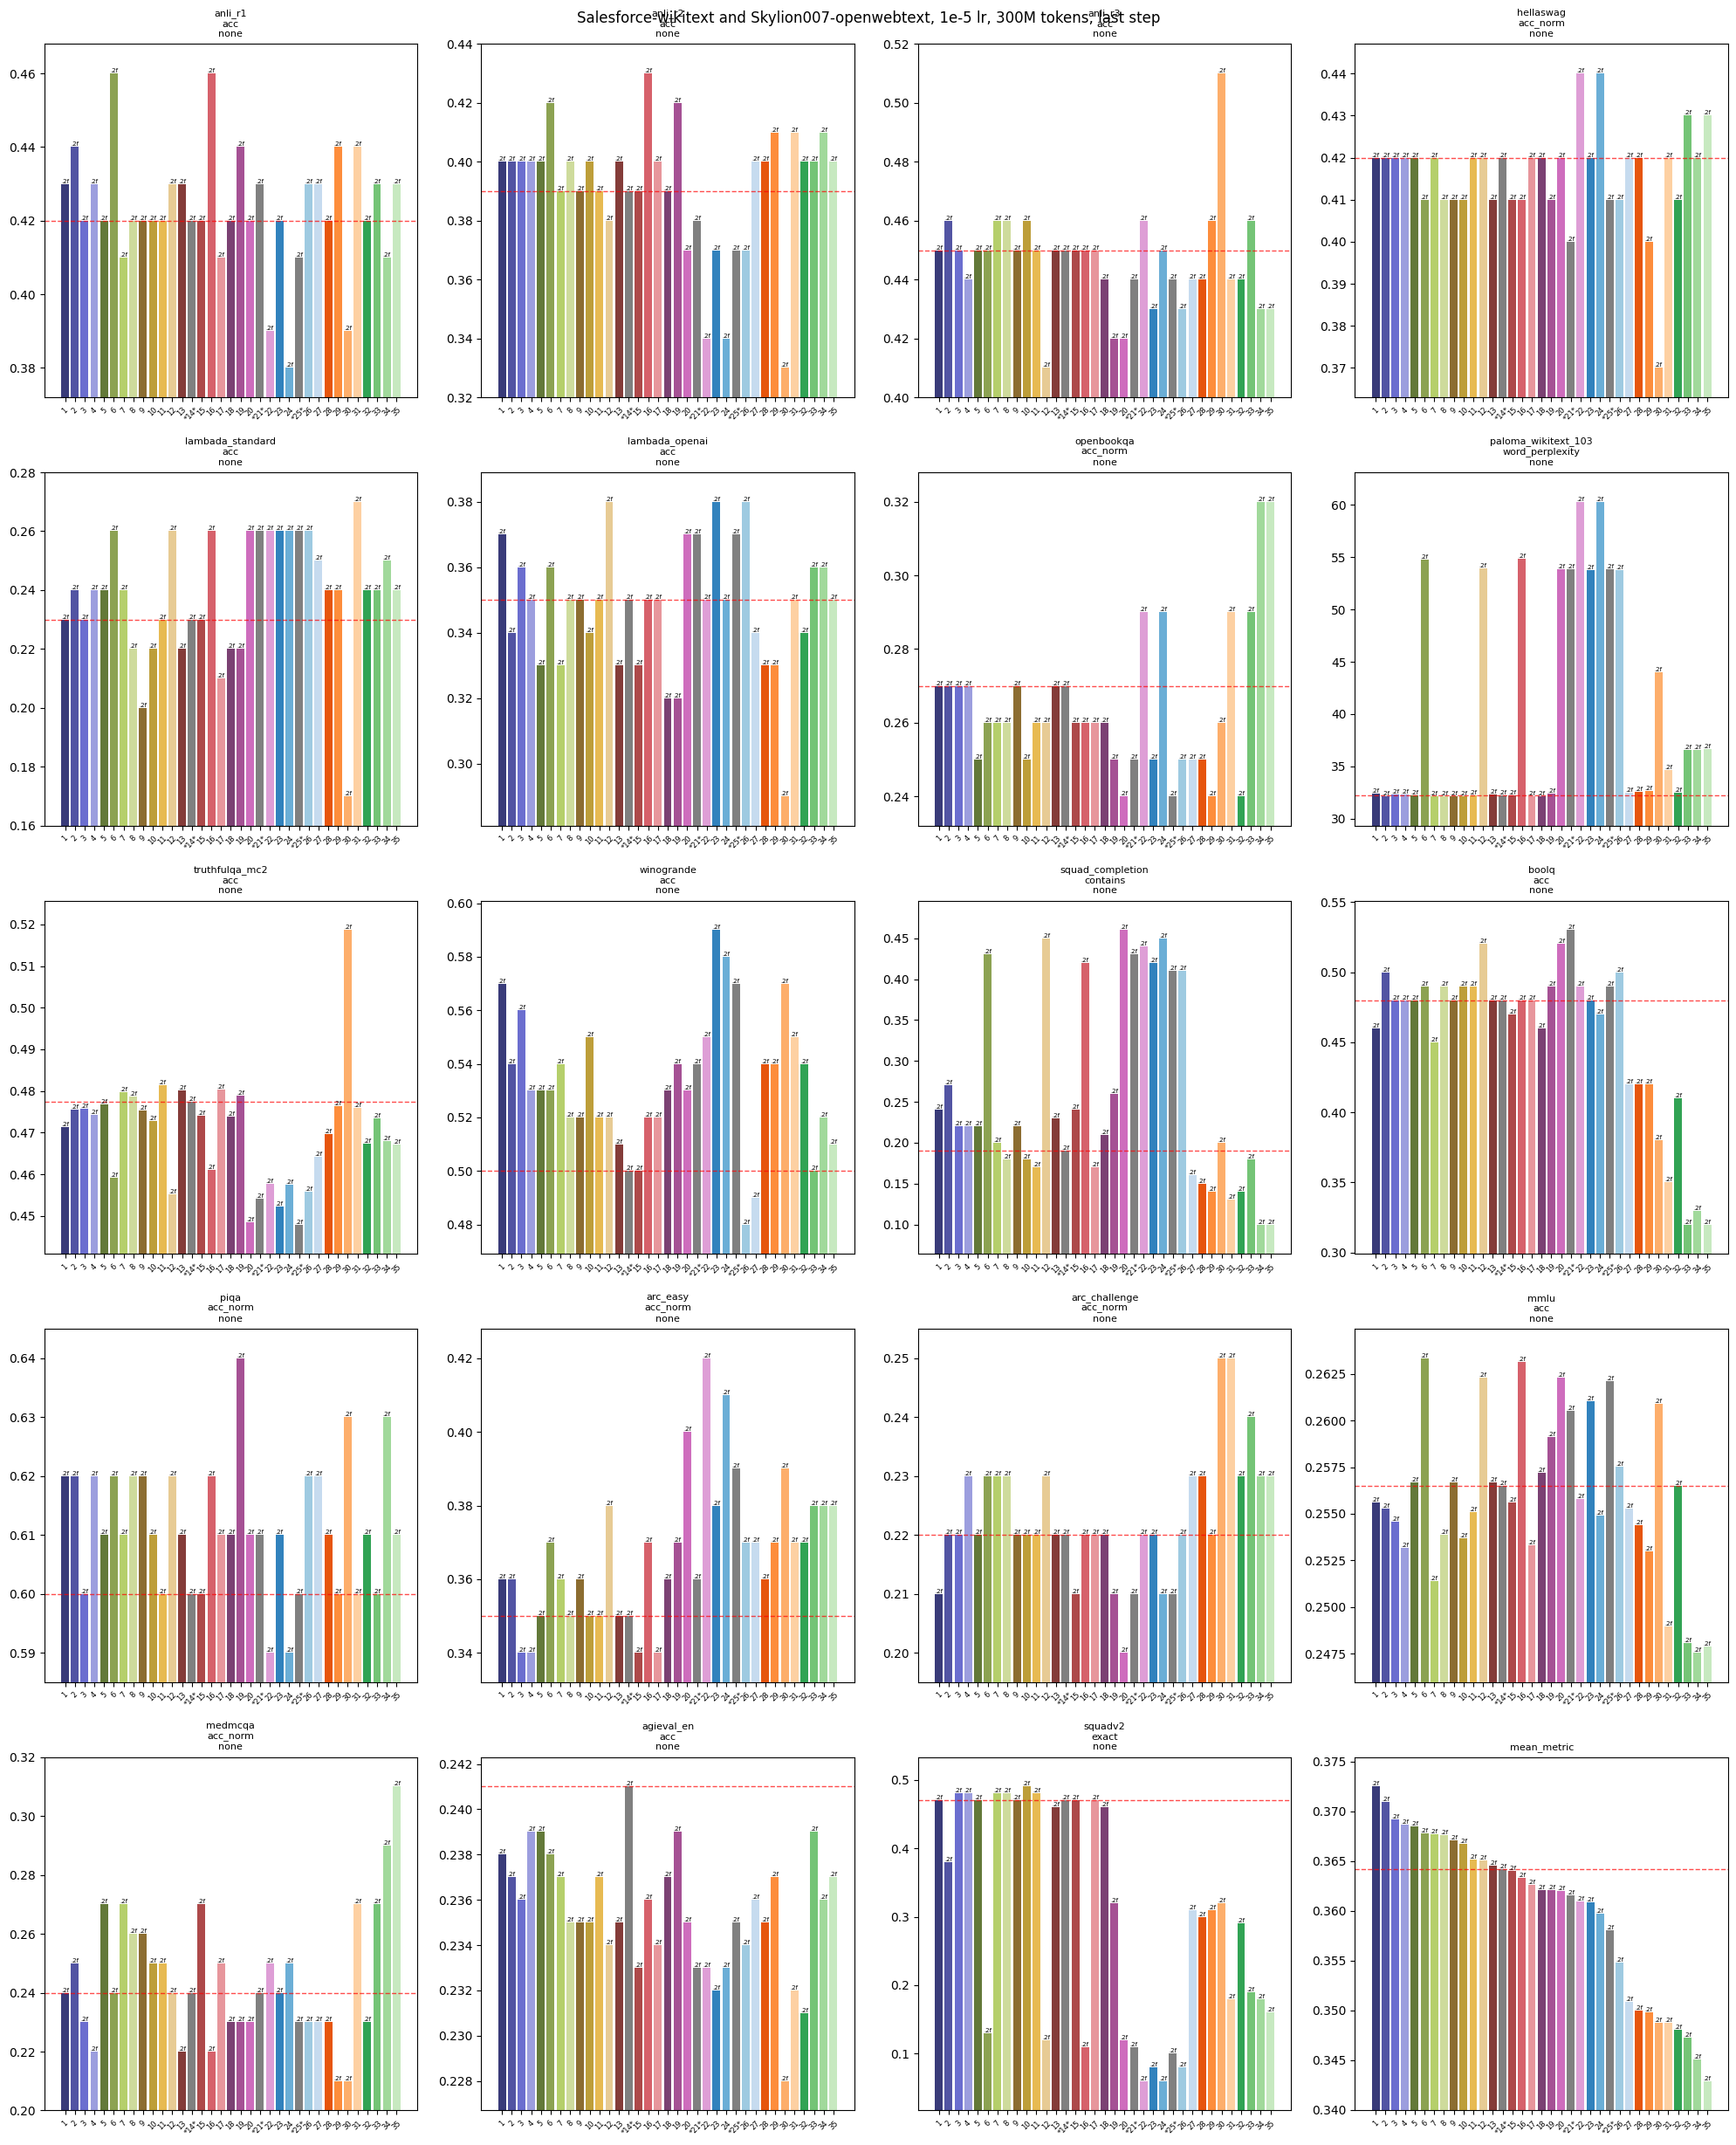

Improvement of best setting over None setting: 0.37-0.36=0.83


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Get colors from two good colormaps
colors1 = plt.cm.tab20b.colors
colors2 = plt.cm.tab20c.colors

# Combine them and create the new map
custom_cmap = ListedColormap(colors1 + colors2)

# Create 'disp' column if it doesn't exist
if 'disp' not in df.columns:
    df['disp'] = df.apply(lambda row: f"{row['disp_type']}-{row['disp_value']}" if pd.notna(row['disp_type']) else 'None', axis=1)

# Filter and sort data
# filtered_df = df[(df['dataset'] == 'Salesforce-wikitext') & (df['step'] == df['step'].max())]
filtered_df = df[(df['step'] == df['step'].max())]


# sorted_df = filtered_df.sort_values('paloma_wikitext_103,word_perplexity,none', ascending=True)
sorted_df = filtered_df.sort_values('mean_metric', ascending=False)

# Identify metric columns (exclude config columns)
config_cols = ['folder_name', 'filename', 'step', 'dataset', 'lr', 'tokens', 'disp_type', 'disp_value', 
               'tau_cosine', 'tau_l2', 'fewshot', 'maxsample', 'seed', 'suffix', 'config_hash', 'gradient_clip', 'disp']
metric_cols = [col for col in df.columns if col not in config_cols]

# Create discrete color map - gray for None, discrete colors for others
none_indices = [i for i, disp_val in enumerate(sorted_df['disp']) if disp_val.startswith('None')]
other_indices = [i for i in range(len(sorted_df)) if i not in none_indices]

# Use tab10 colormap for discrete colors
cmap = custom_cmap
colors = ['gray'] * len(sorted_df)  # Start with all gray
for i, idx in enumerate(other_indices):
    colors[idx] = cmap(i)  # Cycle through 10 discrete colors

# Get None values for reference lines
none_values = {}
for metric in metric_cols:
    none_row = sorted_df[sorted_df['disp'].str.startswith('None')]
    if not none_row.empty:
        none_values[metric] = none_row[metric].iloc[0]
    else:
        none_values[metric] = None

# Create subplots
n_metrics = len(metric_cols)
n_cols = 4
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Plot each metric
for i, metric in enumerate(metric_cols):
    row, col = i // n_cols, i % n_cols
    ax = axes[row, col]
    
    values = sorted_df[metric].values
    bars = ax.bar(range(len(sorted_df)), values, color=colors)
    
    # Set y-axis limits with margin
    if len(values) > 0:
        y_min = np.min(values)
        y_max = np.max(values)
        y_margin = (y_max - y_min) * 0.1 if y_max != y_min else abs(y_min) * 0.1
        ax.set_ylim(y_min - y_margin, y_max + y_margin)
    
    ax.set_title(metric.replace(',', '\n'), fontsize=8)
    ax.set_xticks(range(len(sorted_df)))
    
    # Create tick labels - highlight None with asterisks
    tick_labels = []
    for j, disp_val in enumerate(sorted_df['disp']):
        if disp_val.startswith('None'):
            tick_labels.append(f"*{j+1}*")  # Special markers for None
        else:
            tick_labels.append(f"{j+1}")
    
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=6)
    
    # Add horizontal dashed line at None value
    if none_values[metric] is not None:
        ax.axhline(y=none_values[metric], color='red', linestyle='--', alpha=0.7, linewidth=1)
    
    # Add value labels on bars (only for significant values)
    for j, v in enumerate(values):
        if abs(v) > 1e-6:  # Only label non-zero values
            ax.text(j, v, '.2f', ha='center', va='bottom' if v >= 0 else 'top', fontsize=5)

# Hide empty subplots
for i in range(n_metrics, n_rows * n_cols):
    row, col = i // n_cols, i % n_cols
    axes[row, col].set_visible(False)

plt.suptitle('Salesforce-wikitext and Skylion007-openwebtext, 1e-5 lr, 300M tokens, last step')
plt.tight_layout()
plt.savefig(f'{output_dir}/metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# # Print the settings for reference
# print("Settings order (best to worst perplexity):")
# print("* = None settings (gray bars)")
# for i, (_, row) in enumerate(sorted_df.iterrows()):
#     marker = "*" if row['disp'].startswith('None') else ""
#     print(f"{marker}{i+1}: {row['disp']} (perplexity: {row['paloma_wikitext_103,word_perplexity,none']:.2f})")

# Get the best and None values
best_value = filtered_df['mean_metric'].max()
none_value = filtered_df.loc[filtered_df['disp'] == 'None-1', 'mean_metric'].iloc[0]
improvement = (best_value - none_value) * 100

print(f"Improvement of best setting over None setting: {best_value:.2f}-{none_value:.2f}={improvement:.2f}")


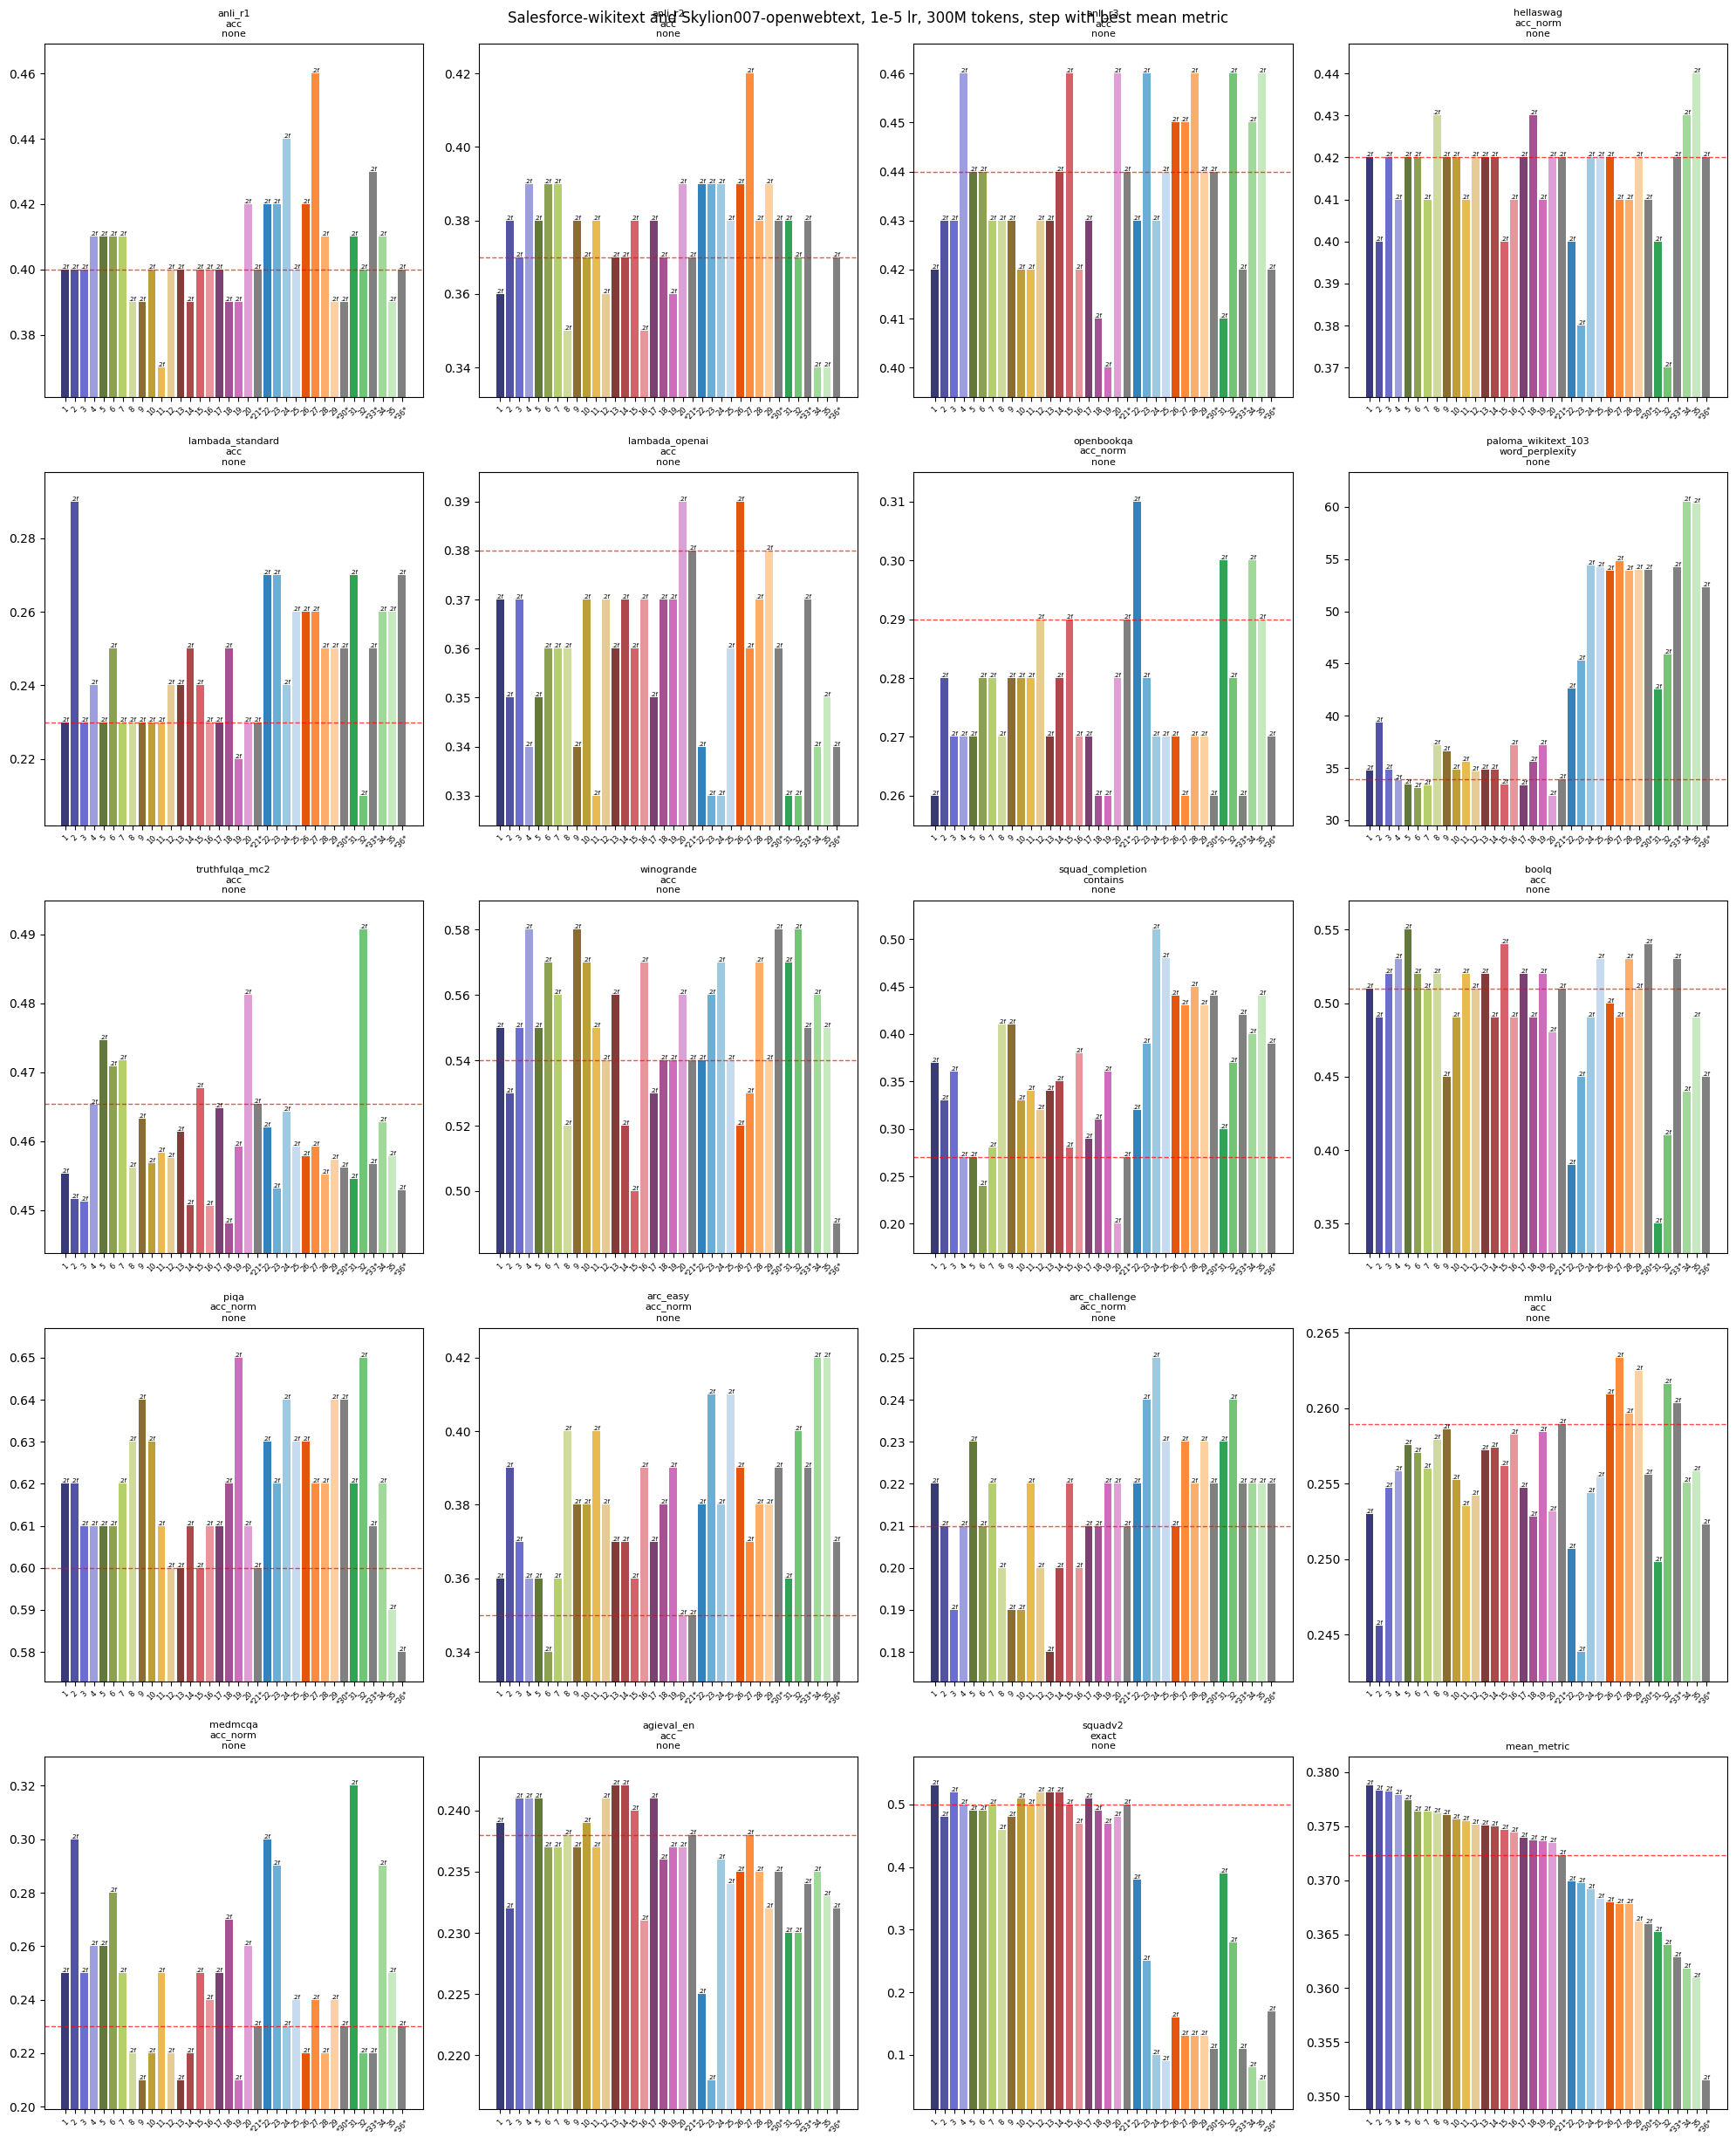

Improvement of best setting over None setting: 0.38-0.37=0.64


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Get colors from two good colormaps
colors1 = plt.cm.tab20b.colors
colors2 = plt.cm.tab20c.colors

# Combine them and create the new map
custom_cmap = ListedColormap(colors1 + colors2)

# Create 'disp' column if it doesn't exist
if 'disp' not in df.columns:
    df['disp'] = df.apply(lambda row: f"{row['disp_type']}-{row['disp_value']}" if pd.notna(row['disp_type']) else 'None', axis=1)

# Filter and sort data
# filtered_df = df[(df['dataset'] == 'Salesforce-wikitext') & (df['step'] == df['step'].max())]
# Replace with: select row with max 'mean_metric' per folder, then filter to Salesforce-wikitext
filtered_df = df.loc[df.groupby('folder_name')['mean_metric'].idxmax()]

# sorted_df = filtered_df.sort_values('paloma_wikitext_103,word_perplexity,none', ascending=True)
sorted_df = filtered_df.sort_values('mean_metric', ascending=False)

# Identify metric columns (exclude config columns)
config_cols = ['folder_name', 'filename', 'step', 'dataset', 'lr', 'tokens', 'disp_type', 'disp_value', 
               'tau_cosine', 'tau_l2', 'fewshot', 'maxsample', 'seed', 'suffix', 'config_hash', 'gradient_clip', 'disp']
metric_cols = [col for col in df.columns if col not in config_cols]

# Create discrete color map - gray for None, discrete colors for others
none_indices = [i for i, disp_val in enumerate(sorted_df['disp']) if disp_val.startswith('None')]
other_indices = [i for i in range(len(sorted_df)) if i not in none_indices]

# Use tab10 colormap for discrete colors
cmap = custom_cmap
colors = ['gray'] * len(sorted_df)  # Start with all gray
for i, idx in enumerate(other_indices):
    colors[idx] = cmap(i)  # Cycle through 10 discrete colors

# Get None values for reference lines
none_values = {}
for metric in metric_cols:
    none_row = sorted_df[sorted_df['disp'].str.startswith('None')]
    if not none_row.empty:
        none_values[metric] = none_row[metric].iloc[0]
    else:
        none_values[metric] = None

# Create subplots
n_metrics = len(metric_cols)
n_cols = 4
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Plot each metric
for i, metric in enumerate(metric_cols):
    row, col = i // n_cols, i % n_cols
    ax = axes[row, col]
    
    values = sorted_df[metric].values
    bars = ax.bar(range(len(sorted_df)), values, color=colors)
    
    # Set y-axis limits with margin
    if len(values) > 0:
        y_min = np.min(values)
        y_max = np.max(values)
        y_margin = (y_max - y_min) * 0.1 if y_max != y_min else abs(y_min) * 0.1
        ax.set_ylim(y_min - y_margin, y_max + y_margin)
    
    ax.set_title(metric.replace(',', '\n'), fontsize=8)
    ax.set_xticks(range(len(sorted_df)))
    
    # Create tick labels - highlight None with asterisks
    tick_labels = []
    for j, disp_val in enumerate(sorted_df['disp']):
        if disp_val.startswith('None'):
            tick_labels.append(f"*{j+1}*")  # Special markers for None
        else:
            tick_labels.append(f"{j+1}")
    
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=6)
    
    # Add horizontal dashed line at None value
    if none_values[metric] is not None:
        ax.axhline(y=none_values[metric], color='red', linestyle='--', alpha=0.7, linewidth=1)
    
    # Add value labels on bars (only for significant values)
    for j, v in enumerate(values):
        if abs(v) > 1e-6:  # Only label non-zero values
            ax.text(j, v, '.2f', ha='center', va='bottom' if v >= 0 else 'top', fontsize=5)

# Hide empty subplots
for i in range(n_metrics, n_rows * n_cols):
    row, col = i // n_cols, i % n_cols
    axes[row, col].set_visible(False)

plt.suptitle('Salesforce-wikitext and Skylion007-openwebtext, 1e-5 lr, 300M tokens, step with best mean metric')
plt.tight_layout()
plt.savefig(f'{output_dir}/metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# # Print the settings for reference
# print("Settings order (best to worst perplexity):")
# print("* = None settings (gray bars)")
# for i, (_, row) in enumerate(sorted_df.iterrows()):
#     marker = "*" if row['disp'].startswith('None') else ""
#     print(f"{marker}{i+1}: {row['disp']} (perplexity: {row['paloma_wikitext_103,word_perplexity,none']:.2f})")

# Get the best and None values
best_value = filtered_df['mean_metric'].max()
none_value = filtered_df.loc[filtered_df['disp'] == 'None-1', 'mean_metric'].iloc[0]
improvement = (best_value - none_value) * 100

print(f"Improvement of best setting over None setting: {best_value:.2f}-{none_value:.2f}={improvement:.2f}")


# Just openwebtext

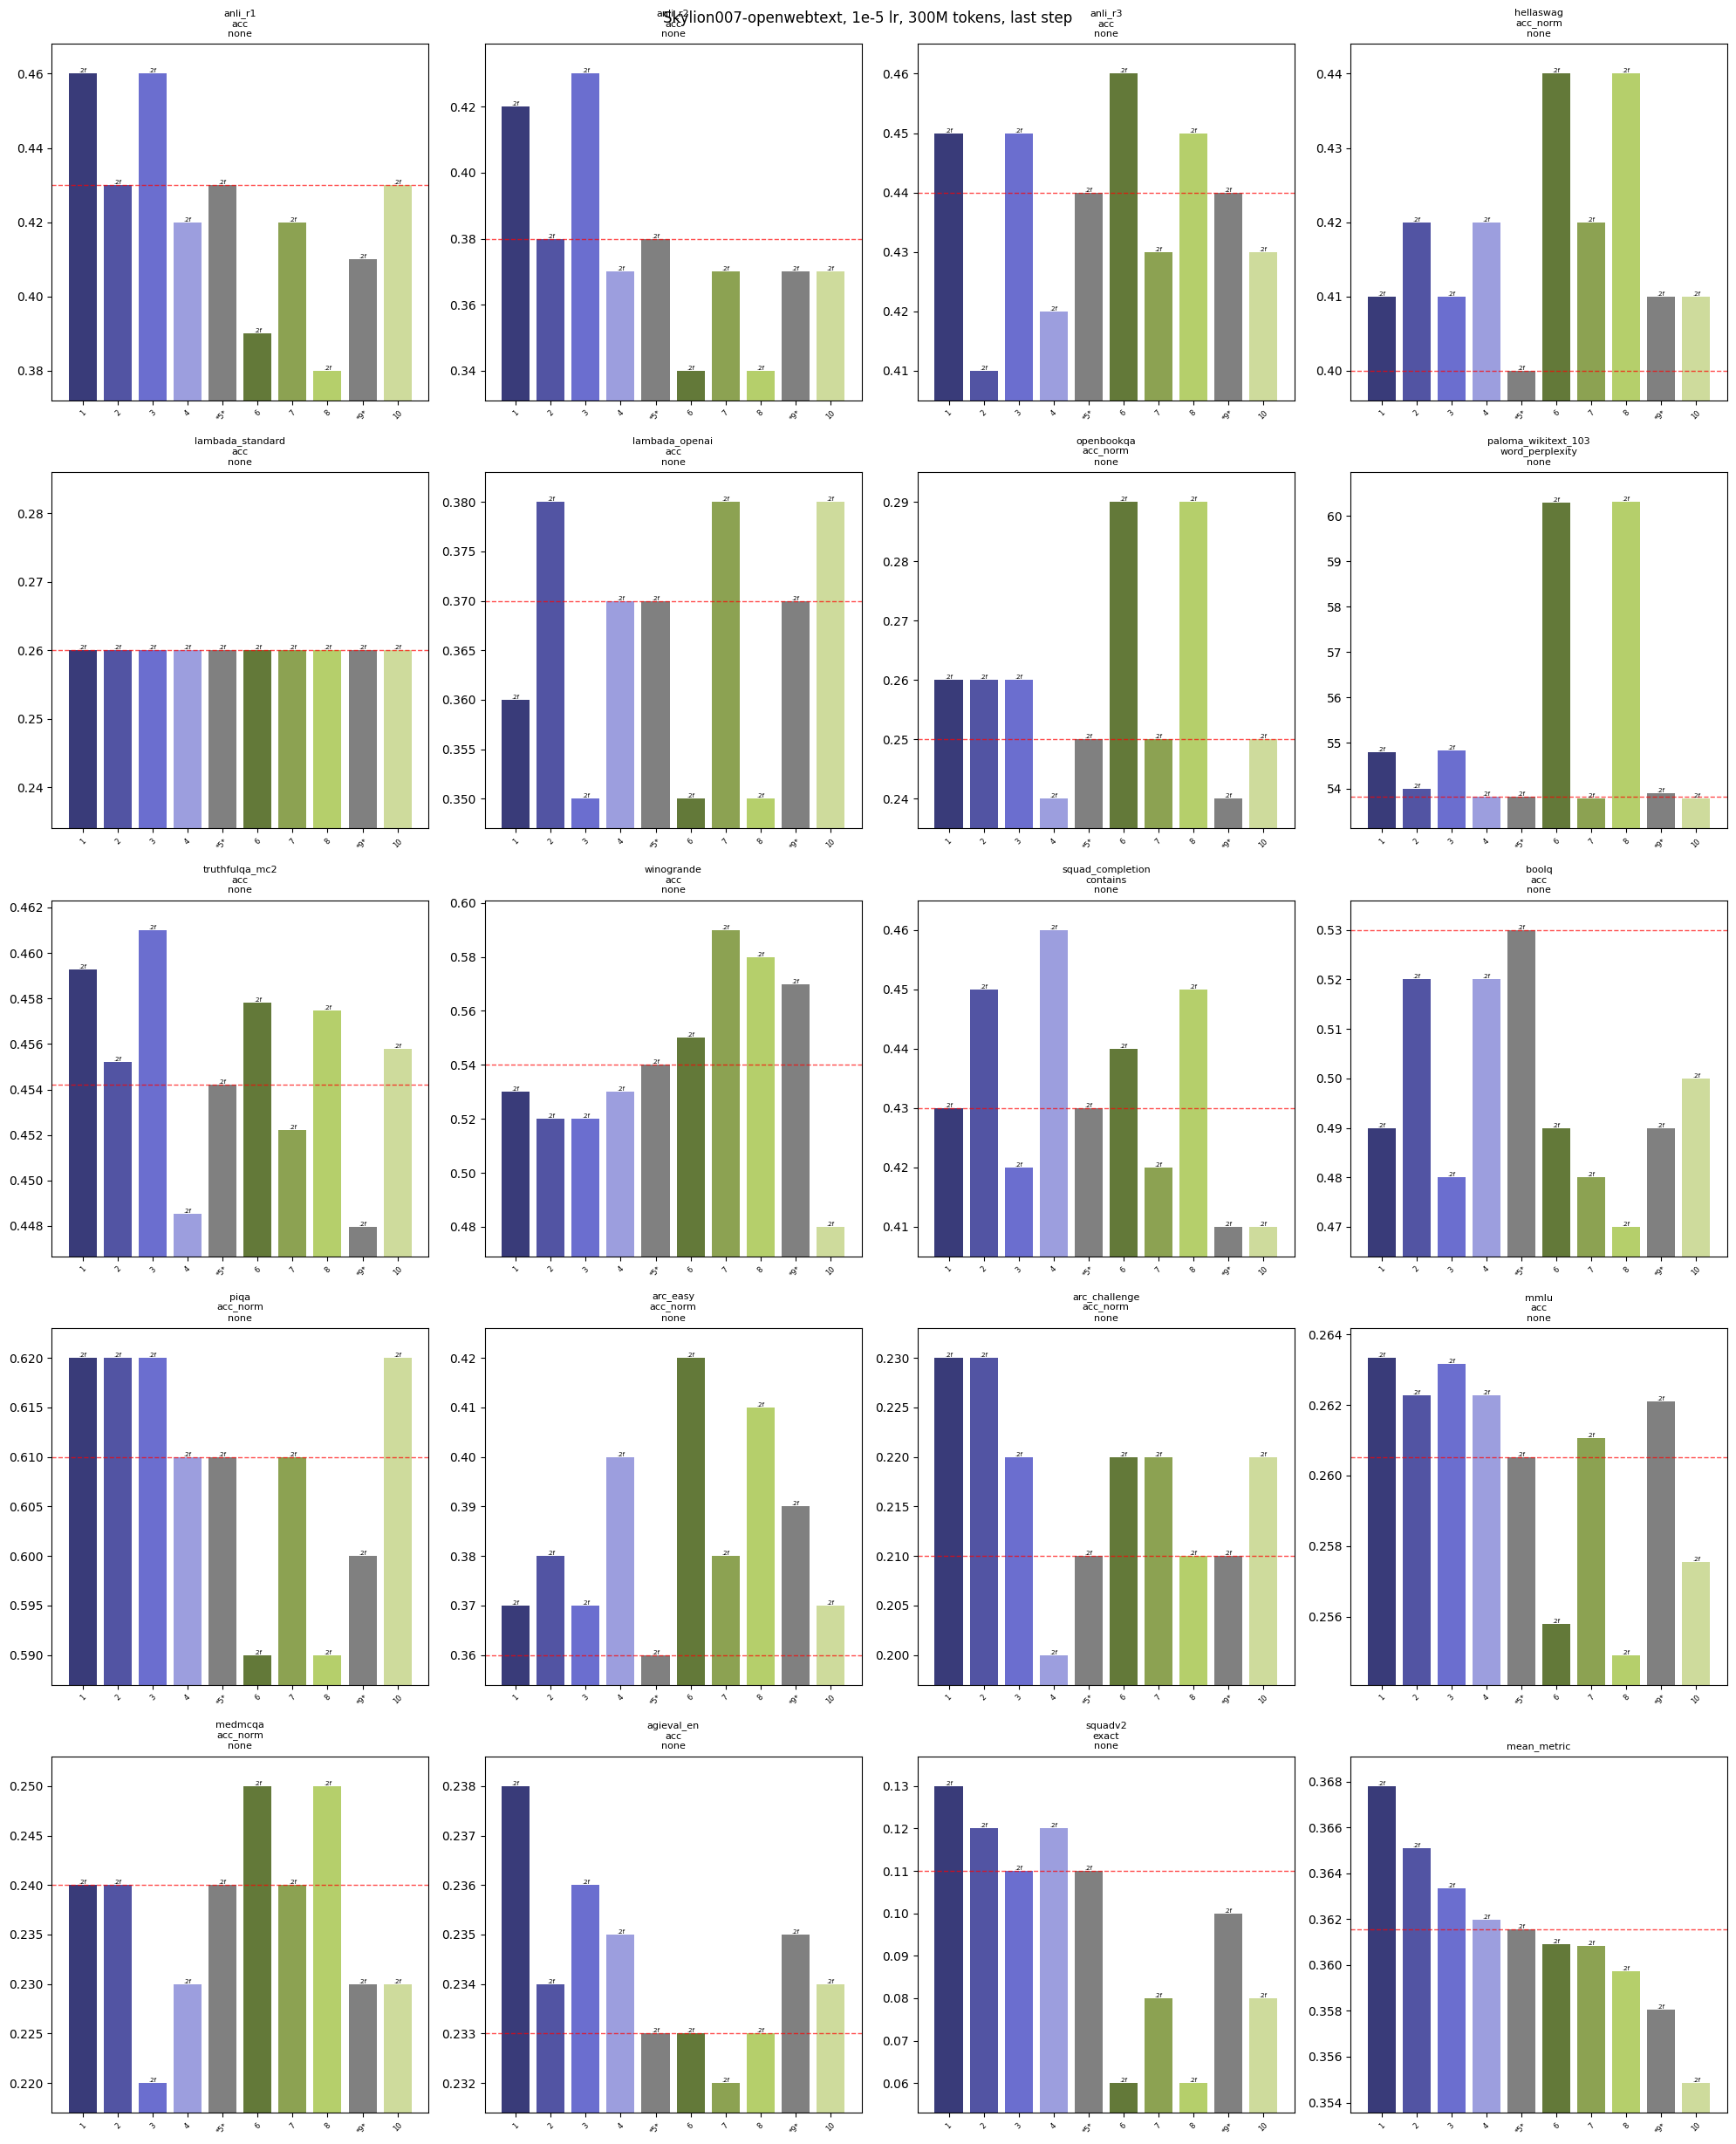

Improvement of best setting over None setting: 0.37-0.36=0.98


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Get colors from two good colormaps
colors1 = plt.cm.tab20b.colors
colors2 = plt.cm.tab20c.colors

# Combine them and create the new map
custom_cmap = ListedColormap(colors1 + colors2)

# Create 'disp' column if it doesn't exist
if 'disp' not in df.columns:
    df['disp'] = df.apply(lambda row: f"{row['disp_type']}-{row['disp_value']}" if pd.notna(row['disp_type']) else 'None', axis=1)

# Filter and sort data
filtered_df = df[(df['dataset'] == 'Skylion007-openwebtext') & (df['step'] == df['step'].max())]
# filtered_df = df[(df['step'] == df['step'].max())]


# sorted_df = filtered_df.sort_values('paloma_wikitext_103,word_perplexity,none', ascending=True)
sorted_df = filtered_df.sort_values('mean_metric', ascending=False)

# Identify metric columns (exclude config columns)
config_cols = ['folder_name', 'filename', 'step', 'dataset', 'lr', 'tokens', 'disp_type', 'disp_value', 
               'tau_cosine', 'tau_l2', 'fewshot', 'maxsample', 'seed', 'suffix', 'config_hash', 'gradient_clip', 'disp']
metric_cols = [col for col in df.columns if col not in config_cols]

# Create discrete color map - gray for None, discrete colors for others
none_indices = [i for i, disp_val in enumerate(sorted_df['disp']) if disp_val.startswith('None')]
other_indices = [i for i in range(len(sorted_df)) if i not in none_indices]

# Use tab10 colormap for discrete colors
cmap = custom_cmap
colors = ['gray'] * len(sorted_df)  # Start with all gray
for i, idx in enumerate(other_indices):
    colors[idx] = cmap(i)  # Cycle through 10 discrete colors

# Get None values for reference lines
none_values = {}
for metric in metric_cols:
    none_row = sorted_df[sorted_df['disp'].str.startswith('None')]
    if not none_row.empty:
        none_values[metric] = none_row[metric].iloc[0]
    else:
        none_values[metric] = None

# Create subplots
n_metrics = len(metric_cols)
n_cols = 4
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Plot each metric
for i, metric in enumerate(metric_cols):
    row, col = i // n_cols, i % n_cols
    ax = axes[row, col]
    
    values = sorted_df[metric].values
    bars = ax.bar(range(len(sorted_df)), values, color=colors)
    
    # Set y-axis limits with margin
    if len(values) > 0:
        y_min = np.min(values)
        y_max = np.max(values)
        y_margin = (y_max - y_min) * 0.1 if y_max != y_min else abs(y_min) * 0.1
        ax.set_ylim(y_min - y_margin, y_max + y_margin)
    
    ax.set_title(metric.replace(',', '\n'), fontsize=8)
    ax.set_xticks(range(len(sorted_df)))
    
    # Create tick labels - highlight None with asterisks
    tick_labels = []
    for j, disp_val in enumerate(sorted_df['disp']):
        if disp_val.startswith('None'):
            tick_labels.append(f"*{j+1}*")  # Special markers for None
        else:
            tick_labels.append(f"{j+1}")
    
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=6)
    
    # Add horizontal dashed line at None value
    if none_values[metric] is not None:
        ax.axhline(y=none_values[metric], color='red', linestyle='--', alpha=0.7, linewidth=1)
    
    # Add value labels on bars (only for significant values)
    for j, v in enumerate(values):
        if abs(v) > 1e-6:  # Only label non-zero values
            ax.text(j, v, '.2f', ha='center', va='bottom' if v >= 0 else 'top', fontsize=5)

# Hide empty subplots
for i in range(n_metrics, n_rows * n_cols):
    row, col = i // n_cols, i % n_cols
    axes[row, col].set_visible(False)

plt.suptitle('Skylion007-openwebtext, 1e-5 lr, 300M tokens, last step')
plt.tight_layout()
plt.savefig(f'{output_dir}/metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# # Print the settings for reference
# print("Settings order (best to worst perplexity):")
# print("* = None settings (gray bars)")
# for i, (_, row) in enumerate(sorted_df.iterrows()):
#     marker = "*" if row['disp'].startswith('None') else ""
#     print(f"{marker}{i+1}: {row['disp']} (perplexity: {row['paloma_wikitext_103,word_perplexity,none']:.2f})")

# Get the best and None values
best_value = filtered_df['mean_metric'].max()
none_value = filtered_df.loc[filtered_df['disp'] == 'None-1', 'mean_metric'].iloc[0]
improvement = (best_value - none_value) * 100

print(f"Improvement of best setting over None setting: {best_value:.2f}-{none_value:.2f}={improvement:.2f}")


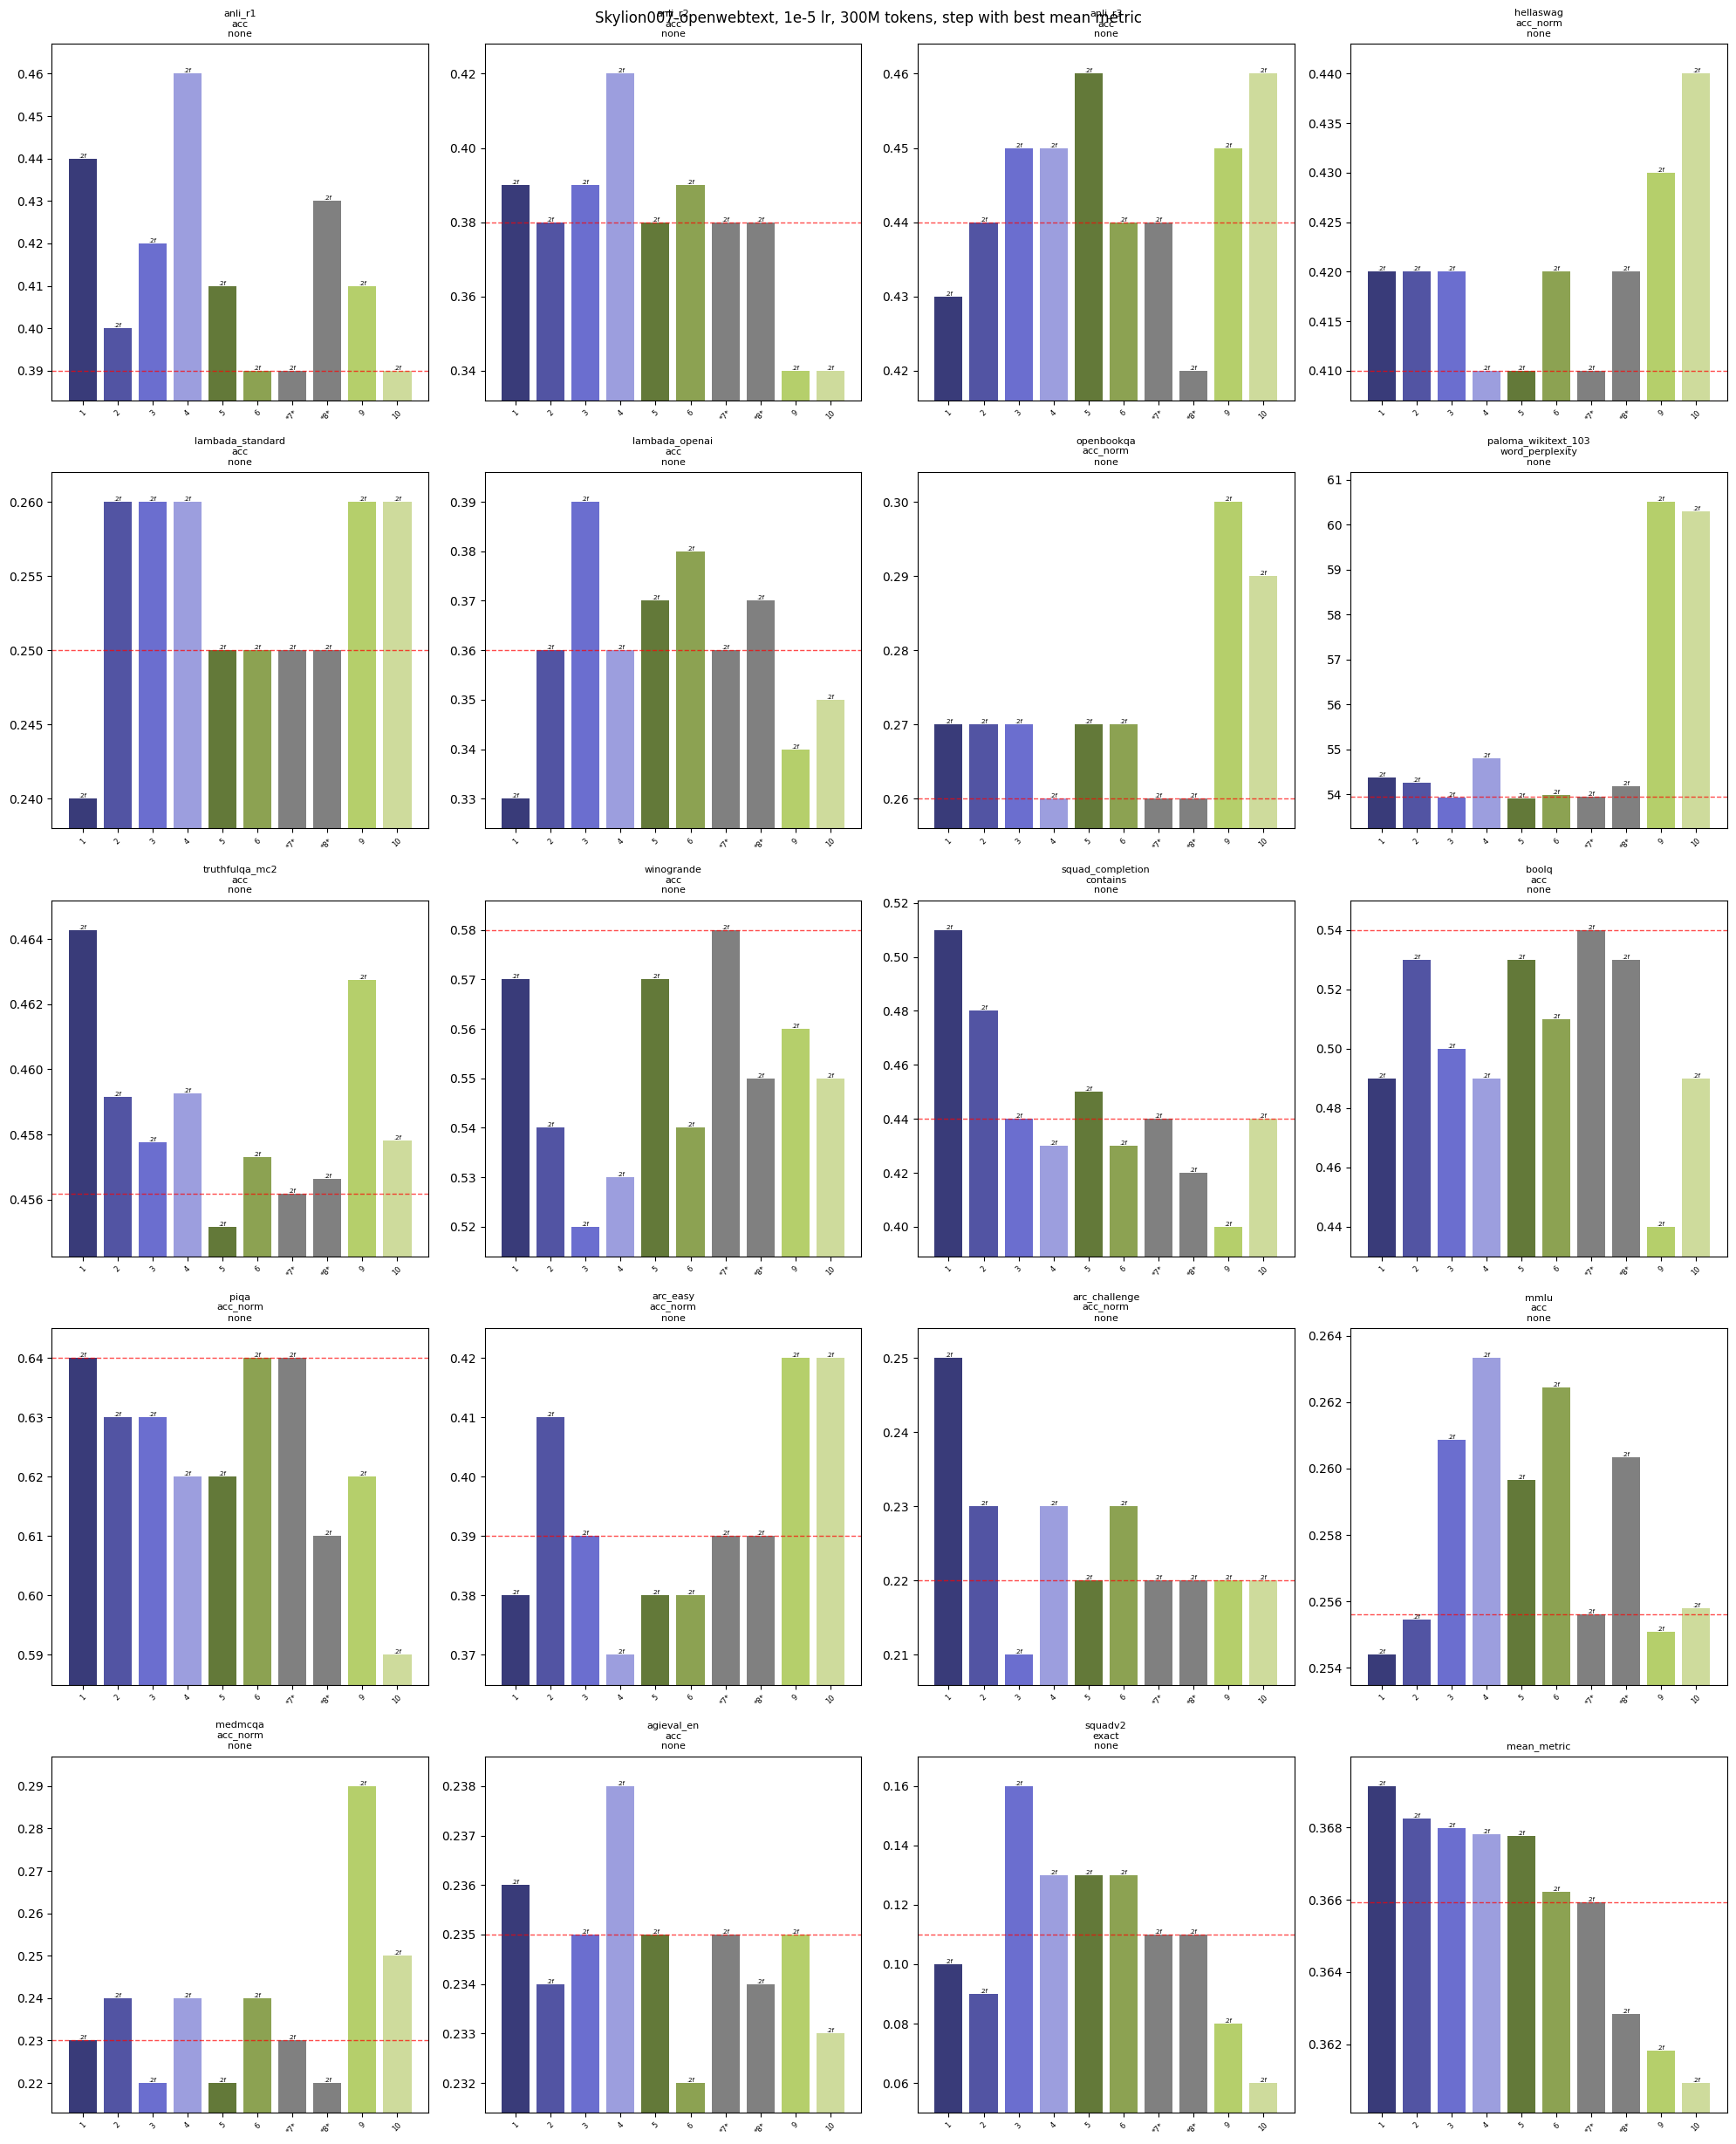

Improvement of best setting over None setting: 0.37-0.36=0.63


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Get colors from two good colormaps
colors1 = plt.cm.tab20b.colors
colors2 = plt.cm.tab20c.colors

# Combine them and create the new map
custom_cmap = ListedColormap(colors1 + colors2)

# Create 'disp' column if it doesn't exist
if 'disp' not in df.columns:
    df['disp'] = df.apply(lambda row: f"{row['disp_type']}-{row['disp_value']}" if pd.notna(row['disp_type']) else 'None', axis=1)

# Filter and sort data
# filtered_df = df[(df['dataset'] == 'Salesforce-wikitext') & (df['step'] == df['step'].max())]
# Replace with: select row with max 'mean_metric' per folder, then filter to Salesforce-wikitext
filtered_df = df.loc[df.groupby('folder_name')['mean_metric'].idxmax()].query('dataset == "Skylion007-openwebtext"')

# sorted_df = filtered_df.sort_values('paloma_wikitext_103,word_perplexity,none', ascending=True)
sorted_df = filtered_df.sort_values('mean_metric', ascending=False)

# Identify metric columns (exclude config columns)
config_cols = ['folder_name', 'filename', 'step', 'dataset', 'lr', 'tokens', 'disp_type', 'disp_value', 
               'tau_cosine', 'tau_l2', 'fewshot', 'maxsample', 'seed', 'suffix', 'config_hash', 'gradient_clip', 'disp']
metric_cols = [col for col in df.columns if col not in config_cols]

# Create discrete color map - gray for None, discrete colors for others
none_indices = [i for i, disp_val in enumerate(sorted_df['disp']) if disp_val.startswith('None')]
other_indices = [i for i in range(len(sorted_df)) if i not in none_indices]

# Use tab10 colormap for discrete colors
cmap = custom_cmap
colors = ['gray'] * len(sorted_df)  # Start with all gray
for i, idx in enumerate(other_indices):
    colors[idx] = cmap(i)  # Cycle through 10 discrete colors

# Get None values for reference lines
none_values = {}
for metric in metric_cols:
    none_row = sorted_df[sorted_df['disp'].str.startswith('None')]
    if not none_row.empty:
        none_values[metric] = none_row[metric].iloc[0]
    else:
        none_values[metric] = None

# Create subplots
n_metrics = len(metric_cols)
n_cols = 4
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Plot each metric
for i, metric in enumerate(metric_cols):
    row, col = i // n_cols, i % n_cols
    ax = axes[row, col]
    
    values = sorted_df[metric].values
    bars = ax.bar(range(len(sorted_df)), values, color=colors)
    
    # Set y-axis limits with margin
    if len(values) > 0:
        y_min = np.min(values)
        y_max = np.max(values)
        y_margin = (y_max - y_min) * 0.1 if y_max != y_min else abs(y_min) * 0.1
        ax.set_ylim(y_min - y_margin, y_max + y_margin)
    
    ax.set_title(metric.replace(',', '\n'), fontsize=8)
    ax.set_xticks(range(len(sorted_df)))
    
    # Create tick labels - highlight None with asterisks
    tick_labels = []
    for j, disp_val in enumerate(sorted_df['disp']):
        if disp_val.startswith('None'):
            tick_labels.append(f"*{j+1}*")  # Special markers for None
        else:
            tick_labels.append(f"{j+1}")
    
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=6)
    
    # Add horizontal dashed line at None value
    if none_values[metric] is not None:
        ax.axhline(y=none_values[metric], color='red', linestyle='--', alpha=0.7, linewidth=1)
    
    # Add value labels on bars (only for significant values)
    for j, v in enumerate(values):
        if abs(v) > 1e-6:  # Only label non-zero values
            ax.text(j, v, '.2f', ha='center', va='bottom' if v >= 0 else 'top', fontsize=5)

# Hide empty subplots
for i in range(n_metrics, n_rows * n_cols):
    row, col = i // n_cols, i % n_cols
    axes[row, col].set_visible(False)

plt.suptitle('Skylion007-openwebtext, 1e-5 lr, 300M tokens, step with best mean metric')
plt.tight_layout()
plt.savefig(f'{output_dir}/metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# # Print the settings for reference
# print("Settings order (best to worst perplexity):")
# print("* = None settings (gray bars)")
# for i, (_, row) in enumerate(sorted_df.iterrows()):
#     marker = "*" if row['disp'].startswith('None') else ""
#     print(f"{marker}{i+1}: {row['disp']} (perplexity: {row['paloma_wikitext_103,word_perplexity,none']:.2f})")

# Get the best and None values
best_value = filtered_df['mean_metric'].max()
none_value = filtered_df.loc[filtered_df['disp'] == 'None-1', 'mean_metric'].iloc[0]
improvement = (best_value - none_value) * 100

print(f"Improvement of best setting over None setting: {best_value:.2f}-{none_value:.2f}={improvement:.2f}")


# look at the values

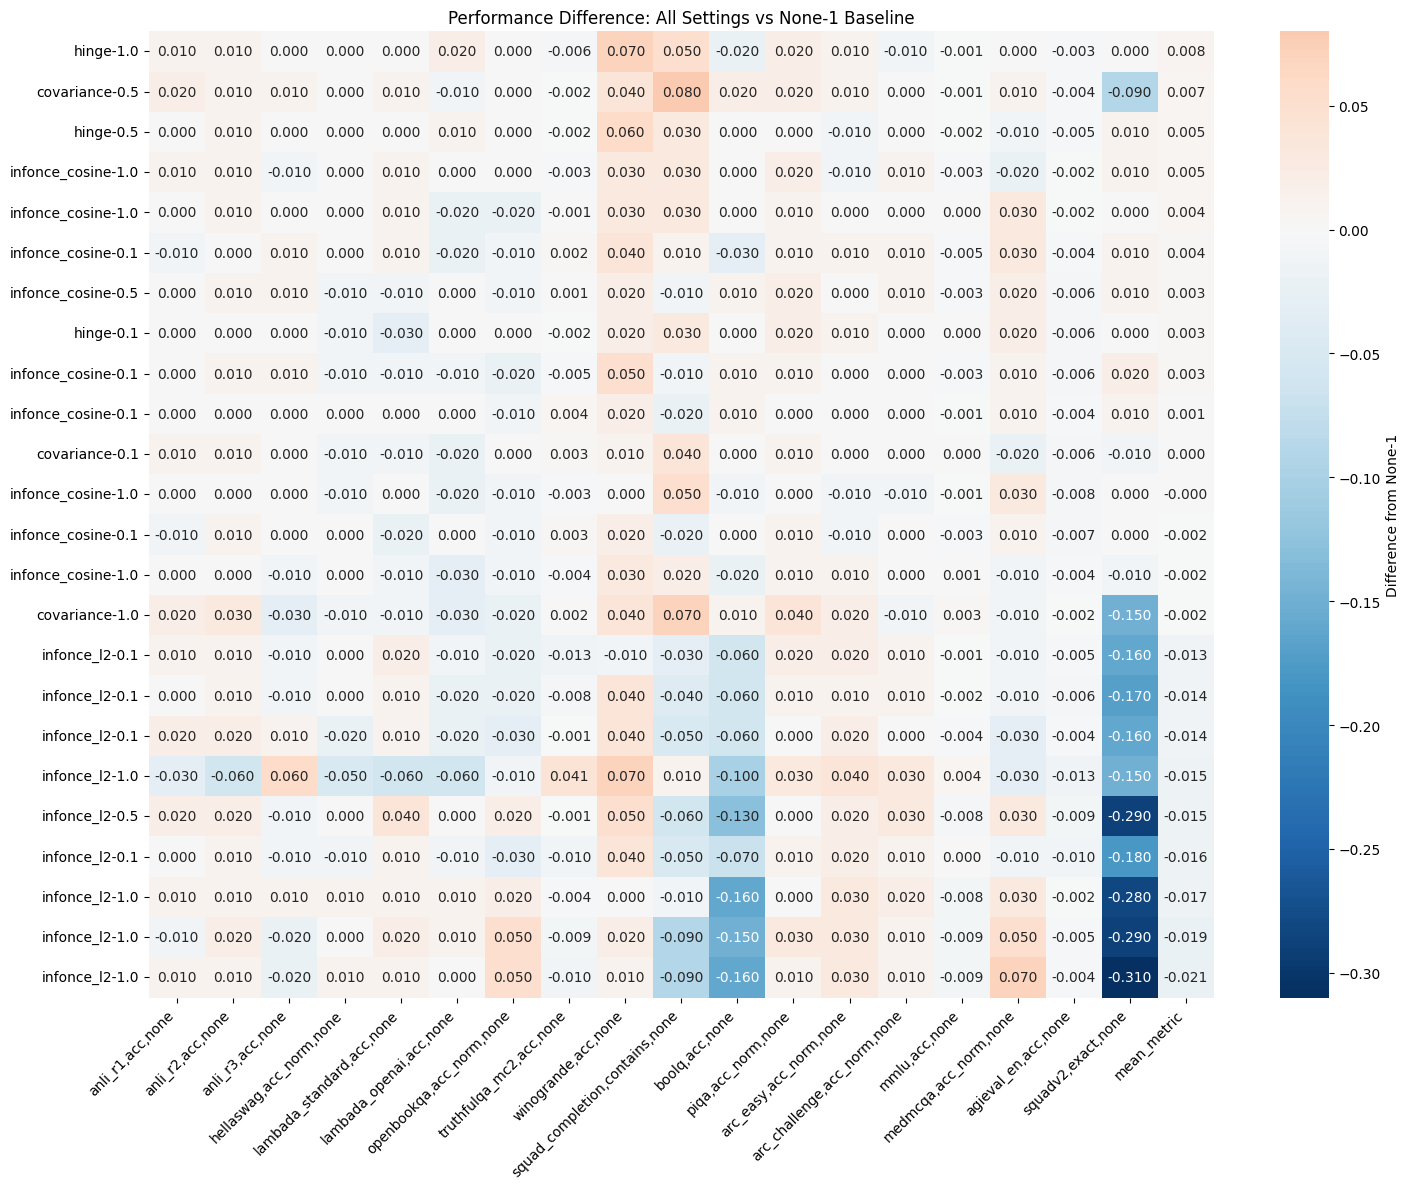

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter and sort data
filtered_df = df[(df['dataset'] == 'Salesforce-wikitext') & (df['step'] == df['step'].max())]
sorted_df = filtered_df.sort_values('mean_metric', ascending=False)

# Get None baseline
none_row = sorted_df.loc[sorted_df['disp'] == 'None-1'][metric_no_ppl + ['mean_metric']].iloc[0]

# Remove None-1 from sorted_df and calculate differences
non_none_df = sorted_df[sorted_df['disp'] != 'None-1']
differences = non_none_df[metric_no_ppl + ['mean_metric']] - none_row

# Create heatmap
plt.figure(figsize=(15, len(non_none_df) * 0.5))
sns.heatmap(differences, 
            xticklabels=metric_no_ppl + ['mean_metric'], 
            yticklabels=non_none_df['disp'].values,
            annot=True, 
            fmt='.3f',
            cmap='RdBu_r',
            center=0,
            cbar_kws={'label': 'Difference from None-1'})
plt.title('Performance Difference: All Settings vs None-1 Baseline')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

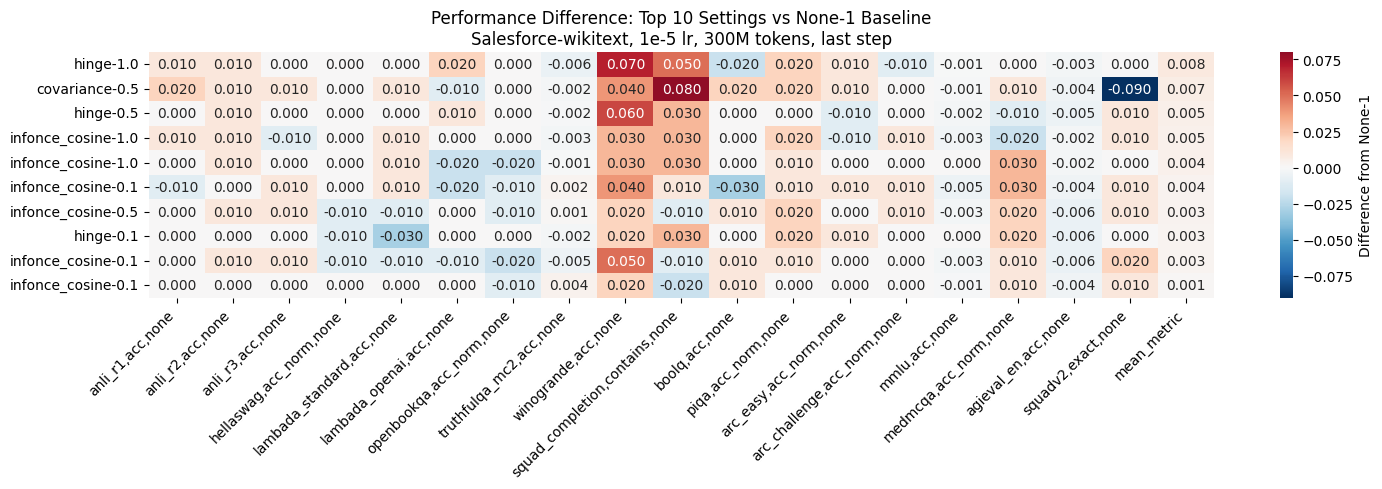

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter and sort data
filtered_df = df[(df['dataset'] == 'Salesforce-wikitext') & (df['step'] == df['step'].max())]
sorted_df = filtered_df.sort_values('mean_metric', ascending=False)

# Get None baseline
none_row = sorted_df.loc[sorted_df['disp'] == 'None-1'][metric_no_ppl + ['mean_metric']].iloc[0]

# Remove None-1 from sorted_df and calculate differences, then take top 10
non_none_df = sorted_df[sorted_df['disp'] != 'None-1'].head(10)
differences = non_none_df[metric_no_ppl + ['mean_metric']] - none_row

# Create heatmap
plt.figure(figsize=(15, len(non_none_df) * 0.5))
sns.heatmap(differences, 
            xticklabels=metric_no_ppl + ['mean_metric'], 
            yticklabels=non_none_df['disp'].values,
            annot=True, 
            fmt='.3f',
            cmap='RdBu_r',
            center=0,
            cbar_kws={'label': 'Difference from None-1'})
plt.title('Performance Difference: Top 10 Settings vs None-1 Baseline\nSalesforce-wikitext, 1e-5 lr, 300M tokens, last step')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

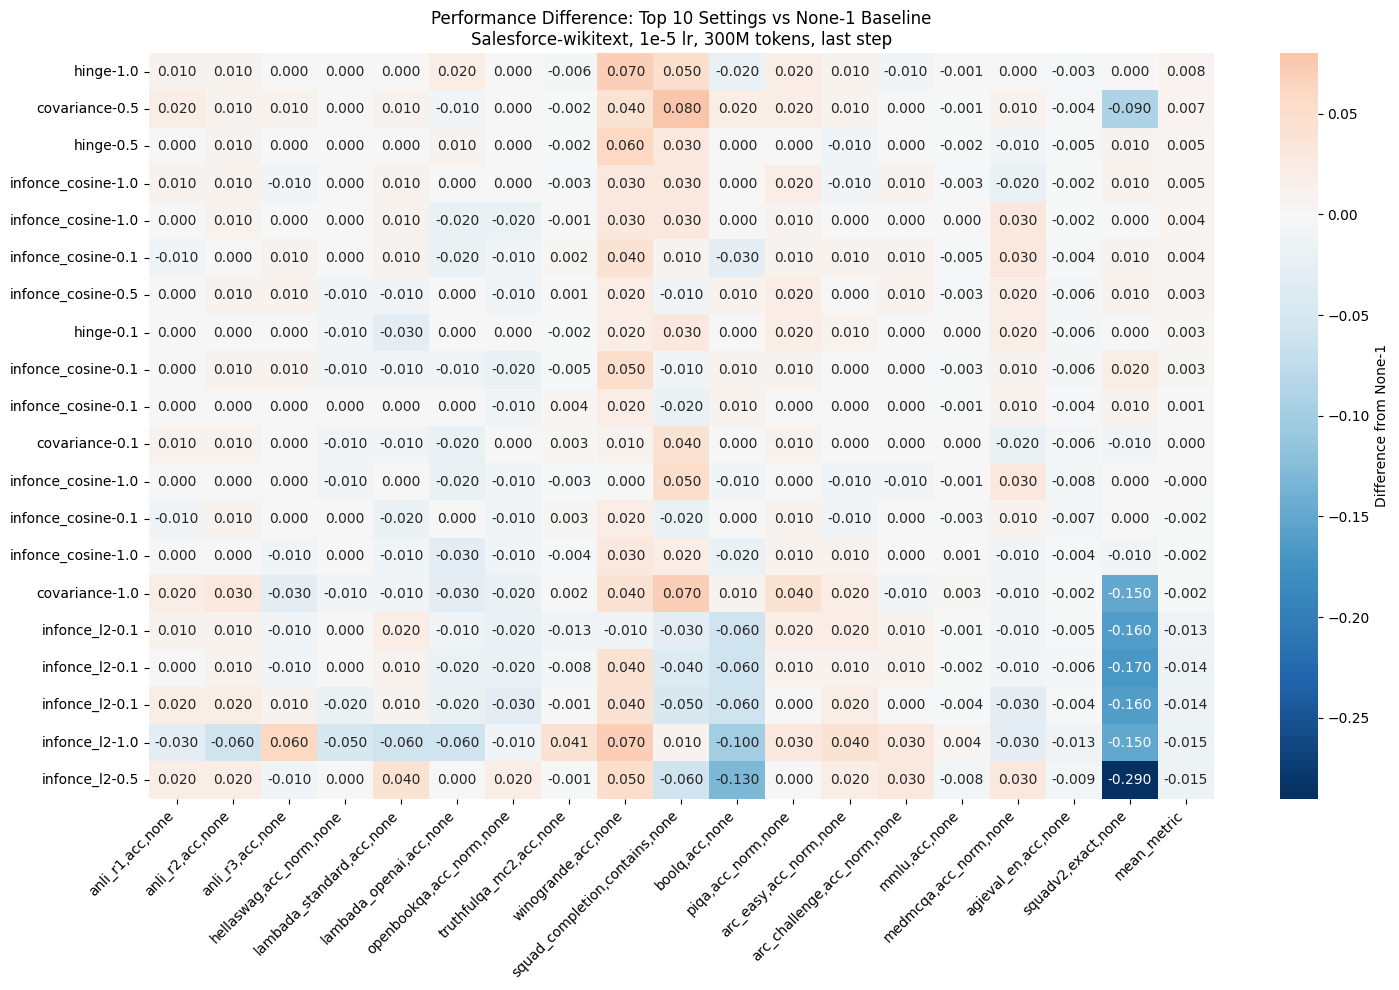

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter and sort data
filtered_df = df[(df['dataset'] == 'Salesforce-wikitext') & (df['step'] == df['step'].max())]
sorted_df = filtered_df.sort_values('mean_metric', ascending=False)

# Get None baseline
none_row = sorted_df.loc[sorted_df['disp'] == 'None-1'][metric_no_ppl + ['mean_metric']].iloc[0]

# Remove None-1 from sorted_df and calculate differences, then take top 10
non_none_df = sorted_df[sorted_df['disp'] != 'None-1'].head(20)
differences = non_none_df[metric_no_ppl + ['mean_metric']] - none_row

# Create heatmap
plt.figure(figsize=(15, len(non_none_df) * 0.5))
sns.heatmap(differences, 
            xticklabels=metric_no_ppl + ['mean_metric'], 
            yticklabels=non_none_df['disp'].values,
            annot=True, 
            fmt='.3f',
            cmap='RdBu_r',
            center=0,
            cbar_kws={'label': 'Difference from None-1'})
plt.title('Performance Difference: Top 10 Settings vs None-1 Baseline\nSalesforce-wikitext, 1e-5 lr, 300M tokens, last step')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [29]:
sorted_df

,folder_name,filename,step,dataset,lr,tokens,disp_type,disp_value,tau_cosine,tau_l2,...,"boolq,acc,none","piqa,acc_norm,none","arc_easy,acc_norm,none","arc_challenge,acc_norm,none","mmlu,acc,none","medmcqa,acc_norm,none","agieval_en,acc,none","squadv2,exact,none",mean_metric,disp
307,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,hinge,1.0,NaN,NaN,...,0.46,0.62,0.36,0.21,0.255614,0.24,0.238,0.47,0.372495,hinge-1.0
241,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,covariance,0.5,NaN,NaN,...,0.50,0.62,0.36,0.22,0.255263,0.25,0.237,0.38,0.370984,covariance-0.5
121,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,hinge,0.5,NaN,NaN,...,0.48,0.60,0.34,0.22,0.254561,0.23,0.236,0.48,0.369236,hinge-0.5
110,midtrain_gpt2_Salesforce-wikitext_infonce_cosi...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,infonce_cosine,1.0,0.1,NaN,...,0.48,0.62,0.34,0.23,0.253158,0.22,0.239,0.48,0.368695,infonce_cosine-1.0
208,midtrain_gpt2_Salesforce-wikitext_infonce_cosi...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,infonce_cosine,1.0,0.5,NaN,...,0.48,0.61,0.35,0.22,0.256667,0.27,0.239,0.47,0.368470,infonce_cosine-1.0
99,midtrain_gpt2_Salesforce-wikitext_infonce_cosi...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,infonce_cosine,0.1,1.0,NaN,...,0.45,0.61,0.36,0.23,0.251404,0.27,0.237,0.48,0.367674,infonce_cosine-0.1
252,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,infonce_cosine,0.5,0.5,NaN,...,0.49,0.62,0.35,0.23,0.253860,0.26,0.235,0.48,0.367644,infonce_cosine-0.5
197,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,hinge,0.1,NaN,NaN,...,0.48,0.62,0.36,0.22,0.256667,0.26,0.235,0.47,0.367059,hinge-0.1
23,midtrain_gpt2_Salesforce-wikitext_infonce_cosi...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,infonce_cosine,0.1,0.1,NaN,...,0.49,0.61,0.35,0.22,0.253684,0.25,0.235,0.49,0.366749,infonce_cosine-0.1
360,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,infonce_cosine,0.1,0.5,NaN,...,0.49,0.60,0.35,0.22,0.255088,0.25,0.237,0.48,0.365195,infonce_cosine-0.1


/tmp/ipykernel_2105676/1106539405.py:53: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


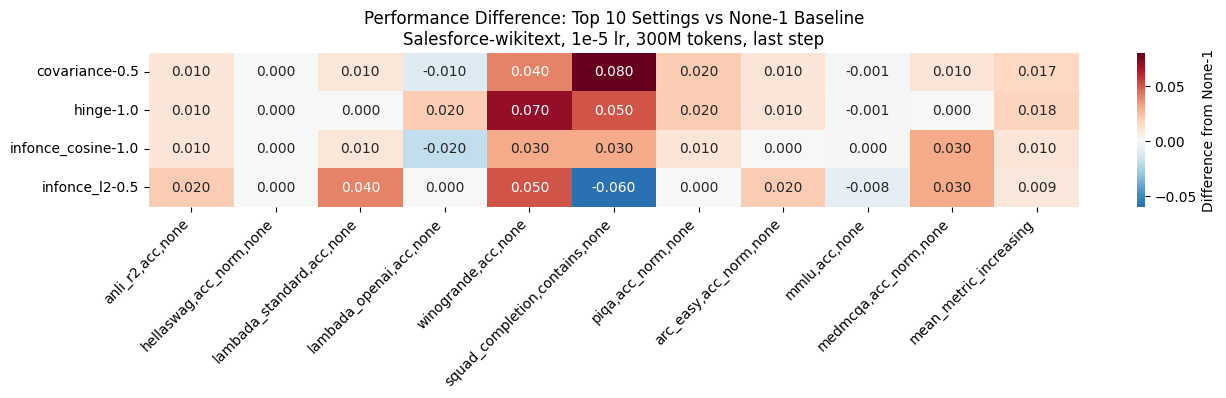

In [32]:
increasing_metrics = [
    "anli_r2",
    "hellaswag",
    "lambada_openai",
    "lambada_standard",
    "winogrande",
    "squad_completion",
    "piqa",
    "arc_easy",
    "mmlu",
    "medmcqa",
] # ones where larger models increase performance.
increasing_metrics_names = [
    i for i in metric_no_ppl if any(metric in i for metric in increasing_metrics)
]
# Assert that all increasing_metrics are included
for metric in increasing_metrics:
    assert any(metric in name for name in increasing_metrics_names), f"Metric '{metric}' not found in metric_no_ppl"
# Create heatmap

df['mean_metric_increasing'] = df[increasing_metrics_names].mean(axis=1)

increasing_metrics_names = [
    i for i in metric_no_ppl if any(metric in i for metric in increasing_metrics)
] + ['mean_metric_increasing']

# Filter and sort data
filtered_df = df[(df['dataset'] == 'Salesforce-wikitext') & (df['step'] == df['step'].max())]
sorted_df = filtered_df.sort_values('mean_metric_increasing', ascending=False)

# Keep only one row per disp_type with the largest mean_metric_increasing
sorted_df = sorted_df.loc[sorted_df.groupby('disp_type')['mean_metric_increasing'].idxmax()]

# Get None baseline
none_row = sorted_df.loc[sorted_df['disp'] == 'None-1'][metric_no_ppl + ['mean_metric_increasing']].iloc[0]

# Remove None-1 from sorted_df and calculate differences, then take top 10
non_none_df = sorted_df[sorted_df['disp'] != 'None-1'].head(20)
differences = non_none_df[metric_no_ppl + ['mean_metric_increasing']] - none_row


plt.figure(figsize=(15, len(non_none_df) * 0.5))
sns.heatmap(differences[increasing_metrics_names], 
            xticklabels=increasing_metrics_names,
            yticklabels=non_none_df['disp'].values,
            annot=True, 
            fmt='.3f',
            cmap='RdBu_r',
            center=0,
            cbar_kws={'label': 'Difference from None-1'})
plt.title('Performance Difference: Top 10 Settings vs None-1 Baseline\nSalesforce-wikitext, 1e-5 lr, 300M tokens, last step')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [40]:
sorted_df.to_csv('./best_res_df.csv', index=False)

In [33]:
none_row

anli_r1,acc,none                  0.420000
anli_r2,acc,none                  0.390000
anli_r3,acc,none                  0.450000
hellaswag,acc_norm,none           0.420000
lambada_standard,acc,none         0.230000
lambada_openai,acc,none           0.350000
openbookqa,acc_norm,none          0.270000
truthfulqa_mc2,acc,none           0.477343
winogrande,acc,none               0.500000
squad_completion,contains,none    0.190000
boolq,acc,none                    0.480000
piqa,acc_norm,none                0.600000
arc_easy,acc_norm,none            0.350000
arc_challenge,acc_norm,none       0.220000
mmlu,acc,none                     0.256491
medmcqa,acc_norm,none             0.240000
agieval_en,acc,none               0.241000
squadv2,exact,none                0.470000
mean_metric_increasing            0.352649
Name: 1, dtype: float64

,folder_name,filename,step,dataset,lr,tokens,disp_type,disp_value,tau_cosine,tau_l2,...,"piqa,acc_norm,none","arc_easy,acc_norm,none","arc_challenge,acc_norm,none","mmlu,acc,none","medmcqa,acc_norm,none","agieval_en,acc,none","squadv2,exact,none",mean_metric,disp,mean_metric_increasing
1,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,None,1,NaN,NaN,...,0.60,0.35,0.22,0.256491,0.24,0.241,0.47,0.364157,None-1,0.352649
241,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,covariance,0.5,NaN,NaN,...,0.62,0.36,0.22,0.255263,0.25,0.237,0.38,0.370984,covariance-0.5,0.369526
307,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,hinge,1.0,NaN,NaN,...,0.62,0.36,0.21,0.255614,0.24,0.238,0.47,0.372495,hinge-1.0,0.370561
208,midtrain_gpt2_Salesforce-wikitext_infonce_cosi...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,infonce_cosine,1.0,0.5,NaN,...,0.61,0.35,0.22,0.256667,0.27,0.239,0.47,0.368470,infonce_cosine-1.0,0.362667
12,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,1e-05,300000000.0,infonce_l2,0.5,NaN,0.5,...,0.60,0.37,0.25,0.248947,0.27,0.232,0.18,0.348712,infonce_l2-0.5,0.361895


In [35]:
sorted_df.columns

Index(['folder_name', 'filename', 'step', 'dataset', 'lr', 'tokens',
       'disp_type', 'disp_value', 'tau_cosine', 'tau_l2', 'fewshot',
       'maxsample', 'seed', 'suffix', 'config_hash', 'gradient_clip',
       'anli_r1,acc,none', 'anli_r2,acc,none', 'anli_r3,acc,none',
       'hellaswag,acc_norm,none', 'lambada_standard,acc,none',
       'lambada_openai,acc,none', 'openbookqa,acc_norm,none',
       'paloma_wikitext_103,word_perplexity,none', 'truthfulqa_mc2,acc,none',
       'winogrande,acc,none', 'squad_completion,contains,none',
       'boolq,acc,none', 'piqa,acc_norm,none', 'arc_easy,acc_norm,none',
       'arc_challenge,acc_norm,none', 'mmlu,acc,none', 'medmcqa,acc_norm,none',
       'agieval_en,acc,none', 'squadv2,exact,none', 'mean_metric', 'disp',
       'mean_metric_increasing'],
      dtype='object')

In [41]:
res_b4_training = pd.read_csv('evals_before_training.csv')

In [42]:
res_b4_training.columns

Index(['model', 'anli_r1,acc,none', 'anli_r2,acc,none', 'anli_r3,acc,none',
       'hellaswag,acc_norm,none', 'lambada_standard,acc,none',
       'lambada_openai,acc,none', 'openbookqa,acc_norm,none',
       'paloma_wikitext_103,word_perplexity,none', 'truthfulqa_mc2,acc,none',
       'winogrande,acc,none', 'squad_completion,contains,none',
       'boolq,acc,none', 'piqa,acc_norm,none', 'arc_easy,acc_norm,none',
       'arc_challenge,acc_norm,none', 'mmlu,acc,none', 'medmcqa,acc_norm,none',
       'agieval_en,acc,none', 'squadv2,exact,none', 'mean_metric'],
      dtype='object')